In [1]:
# Ejecuta este código de verificación
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

r = requests.get(url)
print(f"Estado: {r.status_code}")
print(f"Primeros 100 caracteres:\n{r.text[:100]}...")
print(f"\n¿Es JSON válido? {r.text.strip().startswith('[') and r.text.strip().endswith(']')}")

Estado: 200
Primeros 100 caracteres:
[{"customerID":"0002-ORFBO","Churn":"No","customer":{"gender":"Female","SeniorCitizen":0,"Partner":"...

¿Es JSON válido? True


In [2]:
import pandas as pd
import json
import requests
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

# 1. Cargar los datos nuevamente
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)

# 2. Crear DataFrame
df = pd.json_normalize(data)
print("Primeras 5 filas del DataFrame original:")
print(df.head())
print("\n" + "="*80 + "\n")

# 3. Información del DataFrame antes de la transformación
print("Información del DataFrame (tipos de datos):")
print(df.info())
print("\n" + "="*80 + "\n")

# 4. Identificar variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas identificadas: {categorical_columns}")
print(f"Número de variables categóricas: {len(categorical_columns)}")
print("\n" + "="*80 + "\n")

# 5. Mostrar valores únicos de algunas variables categóricas importantes
print("Valores únicos en variables categóricas clave:")
print("\nChurn:", df['Churn'].unique())
print("gender:", df['customer.gender'].unique())
print("Partner:", df['customer.Partner'].unique())
print("Dependents:", df['customer.Dependents'].unique())
print("InternetService:", df['internet.InternetService'].unique())
print("Contract:", df['account.Contract'].unique())
print("PaymentMethod:", df['account.PaymentMethod'].unique())
print("\n" + "="*80 + "\n")

# 6. APLICAR ONE-HOT ENCODING
print("APLICANDO ONE-HOT ENCODING...\n")

# Seleccionar columnas categóricas para one-hot encoding (excluyendo customerID que es un identificador)
columns_to_encode = [col for col in categorical_columns if col != 'customerID']

# Aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones después de one-hot encoding: {df_encoded.shape}")
print(f"Columnas originales: {len(df.columns)}")
print(f"Columnas después de encoding: {len(df_encoded.columns)}")
print("\n" + "="*80 + "\n")

# 7. Mostrar las nuevas columnas creadas (solo algunas como ejemplo)
print("Ejemplo de nuevas columnas creadas (primeras 10):")
new_columns = [col for col in df_encoded.columns if col not in df.columns]
print(new_columns[:10])
print("\n" + "="*80 + "\n")

# 8. Verificar que todas las columnas son numéricas ahora
print("Tipos de datos después del encoding:")
print(df_encoded.dtypes.value_counts())
print("\n" + "="*80 + "\n")

# 9. MÉTODO ALTERNATIVO: Label Encoding para variables ordinales
# (para variables que tienen un orden natural)
print("MÉTODO ALTERNATIVO - Label Encoding para variables ordinales:\n")

# Crear una copia del DataFrame original
df_label = df.copy()

# Variables que podrían tener un orden (Contract, por ejemplo)
label_encoders = {}
ordinal_columns = ['account.Contract']  # Contract tiene orden: Month-to-month < One year < Two year

for col in ordinal_columns:
    le = LabelEncoder()
    df_label[col + '_label'] = le.fit_transform(df_label[col])
    label_encoders[col] = le
    print(f"{col}:")
    print(f"  Categorías originales: {le.classes_}")
    print(f"  Valores numéricos asignados: {list(range(len(le.classes_)))}")

print("\n" + "="*80 + "\n")

# 10. Comparativa de los métodos
print("COMPARATIVA DE MÉTODOS DE CODIFICACIÓN:\n")
print("One-Hot Encoding (recomendado para la mayoría de casos):")
print("- Crea columnas binarias para cada categoría")
print("- No asume orden entre categorías")
print("- Evita relaciones ordinales incorrectas")
print(f"- Número de columnas resultantes: {df_encoded.shape[1]}")
print("\nLabel Encoding:")
print("- Asigna números enteros a cada categoría")
print("- Asume un orden implícito (puede ser problemático si no existe)")
print("- Más eficiente en memoria (menos columnas)")
print(f"- Número de columnas resultantes: {df_label.shape[1]}")
print("\n" + "="*80 + "\n")

# 11. Guardar el DataFrame transformado (opcional)
# df_encoded.to_csv('telecom_data_encoded.csv', index=False)
# print("DataFrame transformado guardado como 'telecom_data_encoded.csv'")

# 12. Mostrar una muestra final de los datos transformados
print("MUESTRA FINAL DE DATOS TRANSFORMADOS (One-Hot Encoding):")
print("Primeras 5 filas y 10 columnas:")
print(df_encoded.iloc[:5, :10])

Primeras 5 filas del DataFrame original:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                

ANÁLISIS DE BALANCE DE CLASES - VARIABLE CHURN

1. FRECUENCIAS ABSOLUTAS (value_counts):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Total de clientes: 7267

2. FRECUENCIAS RELATIVAS (porcentajes):
Churn
No     71.20
Yes    25.72
        3.08
Name: proportion, dtype: float64

MÉTRICAS DE DESBALANCE

Ratio de desbalance (No/Yes): 2.77:1
(Por cada cliente que canceló, 2.77 permanecen)

Clase minoritaria: 'Yes' con 25.7% de los datos
Nivel de desbalance: DESBALANCE SIGNIFICATIVO

VISUALIZACIÓN DEL BALANCE


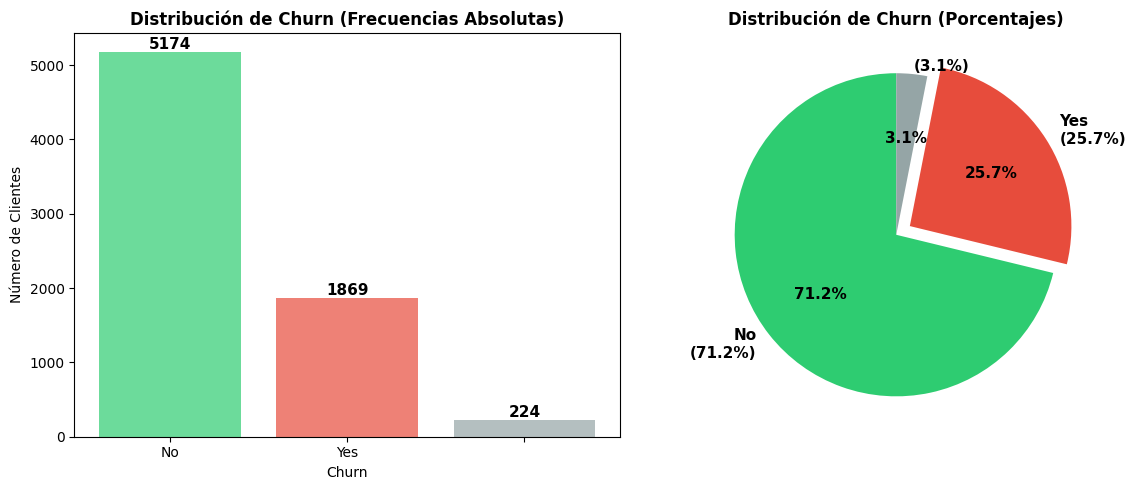


ANÁLISIS DE CHURN POR SEGMENTOS

3.1 CHURN POR GÉNERO:
Churn                     No    Yes
customer.gender                    
Female           2.90  70.96  26.14
Male             3.27  71.43  25.31

3.2 CHURN POR TIPO DE CONTRATO:
Churn                      No    Yes
account.Contract                    
Month-to-month    3.25  55.43  41.32
One year          3.03  86.04  10.93
Two year          2.75  94.49   2.75

3.3 CHURN POR TIPO DE INTERNET:
Churn                              No    Yes
internet.InternetService                    
DSL                       2.69  78.86  18.45
Fiber optic               3.19  56.25  40.56
No                        3.48  89.37   7.15

IMPLICACIONES PARA EL MODELADO PREDICTIVO

Este nivel de desbalance puede afectar al modelo de las siguientes formas:

• El modelo tenderá a predecir la clase mayoritaria ('No') con mayor frecuencia
• La exactitud (accuracy) puede ser engañosa (si predice siempre 'No', tendría ~73% de precisión)
• Las métricas como precis

In [10]:
import pandas as pd
import json
import requests
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar los datos nuevamente
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)

# 2. Crear DataFrame
df = pd.json_normalize(data)

# 3. ANALIZAR EL BALANCE DE CLASES CON VALUE_COUNTS()
print("="*60)
print("ANÁLISIS DE BALANCE DE CLASES - VARIABLE CHURN")
print("="*60)

# Calcular frecuencias absolutas
churn_counts = df['Churn'].value_counts()
print("\n1. FRECUENCIAS ABSOLUTAS (value_counts):")
print(churn_counts)
print(f"\nTotal de clientes: {len(df)}")

# Calcular frecuencias relativas (porcentajes)
churn_percentages = df['Churn'].value_counts(normalize=True) * 100
print("\n2. FRECUENCIAS RELATIVAS (porcentajes):")
print(churn_percentages.round(2))

# 4. MÉTRICAS DE DESBALANCE
print("\n" + "="*60)
print("MÉTRICAS DE DESBALANCE")
print("="*60)

# Obtener valores específicos
no_churn = churn_counts.get('No', 0)
yes_churn = churn_counts.get('Yes', 0)
total = len(df)

# Calcular ratio de desbalance
if yes_churn > 0:
    imbalance_ratio = no_churn / yes_churn
    print(f"\nRatio de desbalance (No/Yes): {imbalance_ratio:.2f}:1")
    print(f"(Por cada cliente que canceló, {imbalance_ratio:.2f} permanecen)")

# Calcular clase minoritaria
minority_class = 'Yes' if yes_churn < no_churn else 'No'
minority_percentage = (min(yes_churn, no_churn) / total) * 100
print(f"\nClase minoritaria: '{minority_class}' con {minority_percentage:.1f}% de los datos")

# Determinar nivel de desbalance
if minority_percentage > 40:
    balance_level = "BALANCEADO"
elif minority_percentage > 30:
    balance_level = "DESBALANCE MODERADO"
elif minority_percentage > 20:
    balance_level = "DESBALANCE SIGNIFICATIVO"
else:
    balance_level = "DESBALANCE SEVERO"

print(f"Nivel de desbalance: {balance_level}")

# 5. VISUALIZACIÓN DEL BALANCE
print("\n" + "="*60)
print("VISUALIZACIÓN DEL BALANCE")
print("="*60)

# Crear gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c', '#95a5a6'] # Added a third color for the extra category
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, alpha=0.7)
axes[0].set_title('Distribución de Churn (Frecuencias Absolutas)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de Clientes')
axes[0].tick_params(axis='both', which='major', labelsize=10)

# Añadir etiquetas con valores
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico de pastel
colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6'] # Added a third color
explode = (0, 0.1, 0)  # Adjusted explode to match the 3 categories
axes[1].pie(churn_percentages.values, labels=[f'{idx}\n({val:.1f}%)' for idx, val in churn_percentages.items()],
            colors=colors_pie, explode=explode, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Distribución de Churn (Porcentajes)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. ANÁLISIS POR SEGMENTOS (opcional)
print("\n" + "="*60)
print("ANÁLISIS DE CHURN POR SEGMENTOS")
print("="*60)

# Churn por género
print("\n3.1 CHURN POR GÉNERO:")
churn_by_gender = pd.crosstab(df['customer.gender'], df['Churn'], normalize='index') * 100
print(churn_by_gender.round(2))

# Churn por tipo de contrato
print("\n3.2 CHURN POR TIPO DE CONTRATO:")
churn_by_contract = pd.crosstab(df['account.Contract'], df['Churn'], normalize='index') * 100
print(churn_by_contract.round(2))

# Churn por servicio de internet
print("\n3.3 CHURN POR TIPO DE INTERNET:")
churn_by_internet = pd.crosstab(df['internet.InternetService'], df['Churn'], normalize='index') * 100
print(churn_by_internet.round(2))

# 7. IMPLICACIONES PARA EL MODELADO
print("\n" + "="*60)
print("IMPLICACIONES PARA EL MODELADO PREDICTIVO")
print("="*60)

print("\nEste nivel de desbalance puede afectar al modelo de las siguientes formas:")
print("\n• El modelo tenderá a predecir la clase mayoritaria ('No') con mayor frecuencia")
print("• La exactitud (accuracy) puede ser engañosa (si predice siempre 'No', tendría ~73% de precisión)")
print("• Las métricas como precisión, recall y F1-score serán más importantes que la exactitud")
print("• La clase minoritaria ('Yes') tendrá menos ejemplos para aprender patrones")

print("\nPOSIBLES ESTRATEGIAS PARA MANEJAR EL DESBALANCE:")
print("1. Técnicas de remuestreo:")
print("   - Oversampling (SMOTE): crear ejemplos sintéticos de la clase minoritaria")
print("   - Undersampling: reducir ejemplos de la clase mayoritaria")
print("2. Usar métricas adecuadas (AUC-ROC, F1-score, precisión/recall)")
print("3. Ajustar pesos de clase en los algoritmos (class_weight='balanced')")
print("4. Usar algoritmos robustos al desbalance como Random Forest o XGBoost")

# 8. RESUMEN FINAL
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"""
📊 **RESUMEN DEL ANÁLISIS DE BALANCE**:

• Total de clientes: {total}
• Clientes activos (No Churn): {no_churn} ({churn_percentages['No']:.1f}%)
• Clientes que cancelaron (Yes Churn): {yes_churn} ({churn_percentages['Yes']:.1f}%)

📈 **MÉTRICAS CLAVE**:
• Ratio de desbalance: {imbalance_ratio:.2f}:1
• Clase minoritaria: {minority_class} ({minority_percentage:.1f}%)
• Nivel de desbalance: {balance_level}

⚠️ **RECOMENDACIÓN**:
Dado que el desbalance es {balance_level.lower()}, se recomienda
implementar técnicas de manejo de desbalance durante el entrenamiento
y utilizar métricas como F1-score y AUC-ROC para evaluar el modelo.
""")

PREPARACIÓN DE DATOS PARA BALANCEO
Dimensiones originales - X: (7267, 6576), y: (7267,)
Distribución original: Counter({False: 5398, True: 1869})
Clase 0 (No Churn): 5398 (74.3%)
Clase 1 (Churn): 1869 (25.7%)

Partición entrenamiento - X_train: (5086, 6576), y_train: Counter({False: 3778, True: 1308})
Partición prueba - X_test: (2181, 6576), y_test: Counter({False: 1620, True: 561})

APLICANDO TÉCNICAS DE BALANCEO

--------------------------------------------------
2.1 RANDOM UNDERSAMPLING
--------------------------------------------------
Distribución después de Undersampling: Counter({False: 1308, True: 1308})
Reducción de datos: 5086 → 2616 muestras

--------------------------------------------------
2.2 RANDOM OVERSAMPLING
--------------------------------------------------
Distribución después de Oversampling: Counter({False: 3778, True: 3778})
Aumento de datos: 5086 → 7556 muestras

--------------------------------------------------
2.3 SMOTE (Synthetic Minority Oversampling)
----

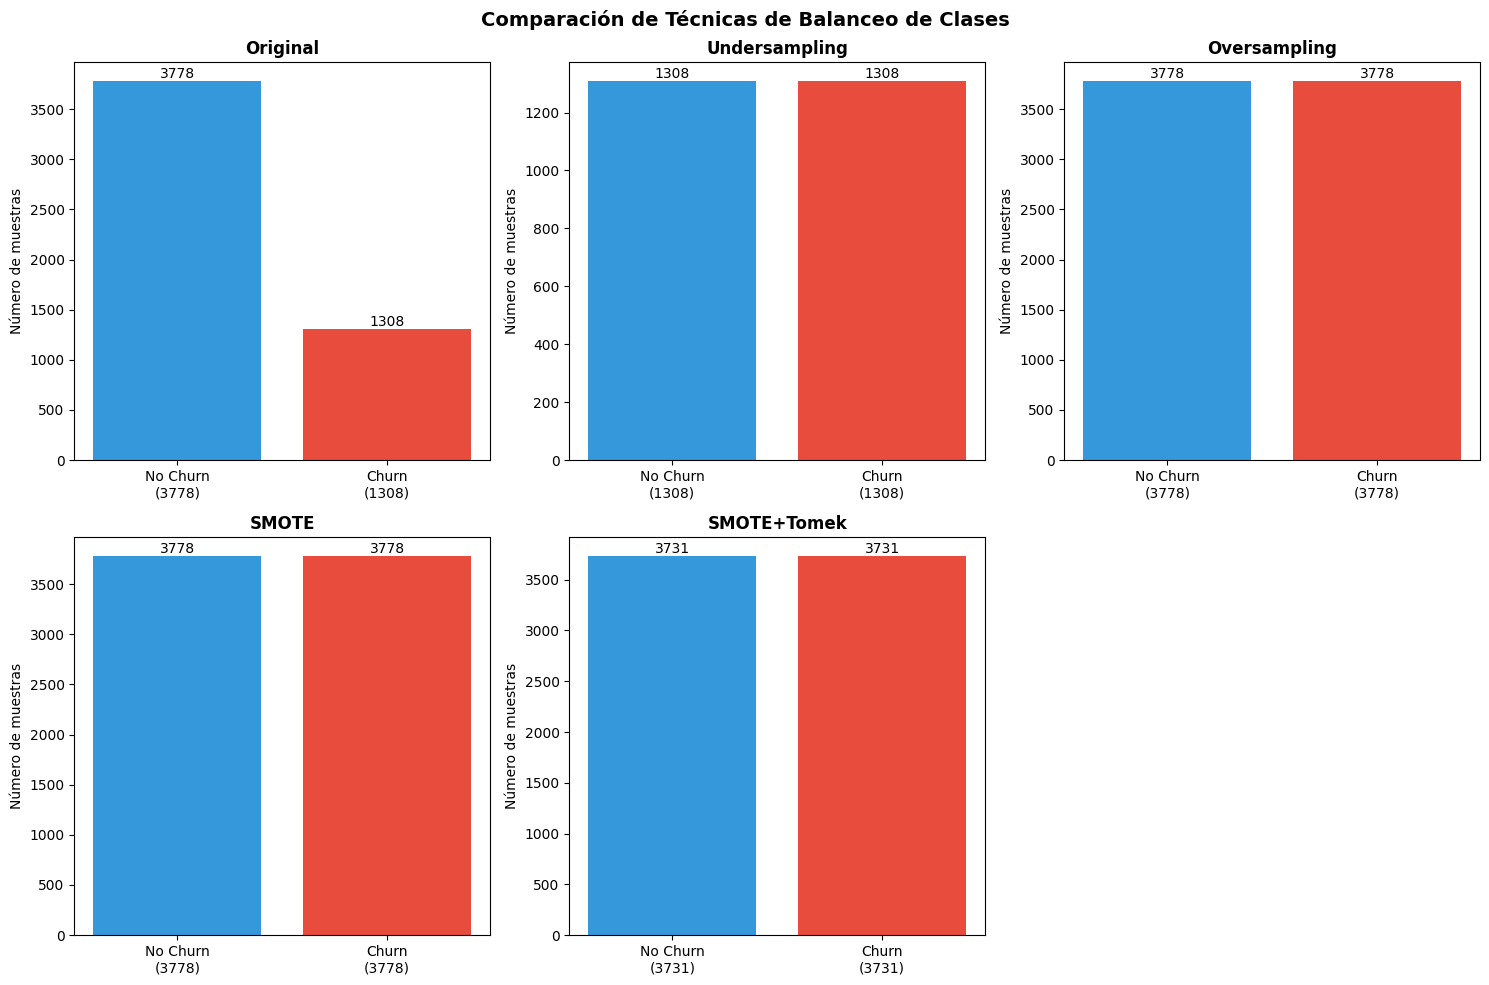


EVALUACIÓN DEL IMPACTO EN MODELOS

Resultados en el conjunto de prueba (con desbalance original):
------------------------------------------------------------
Técnica         F1-Score     AUC-ROC      Mejora vs Original
------------------------------------------------------------
Original        0.5130       0.8209      -         
Undersampling   0.6050       0.8257      +9.20%    
Oversampling    0.5740       0.8183      +6.10%    
SMOTE           0.5573       0.8179      +4.44%    
SMOTE+Tomek     0.5722       0.8244      +5.93%    

MATRICES DE CONFUSIÓN COMPARATIVAS


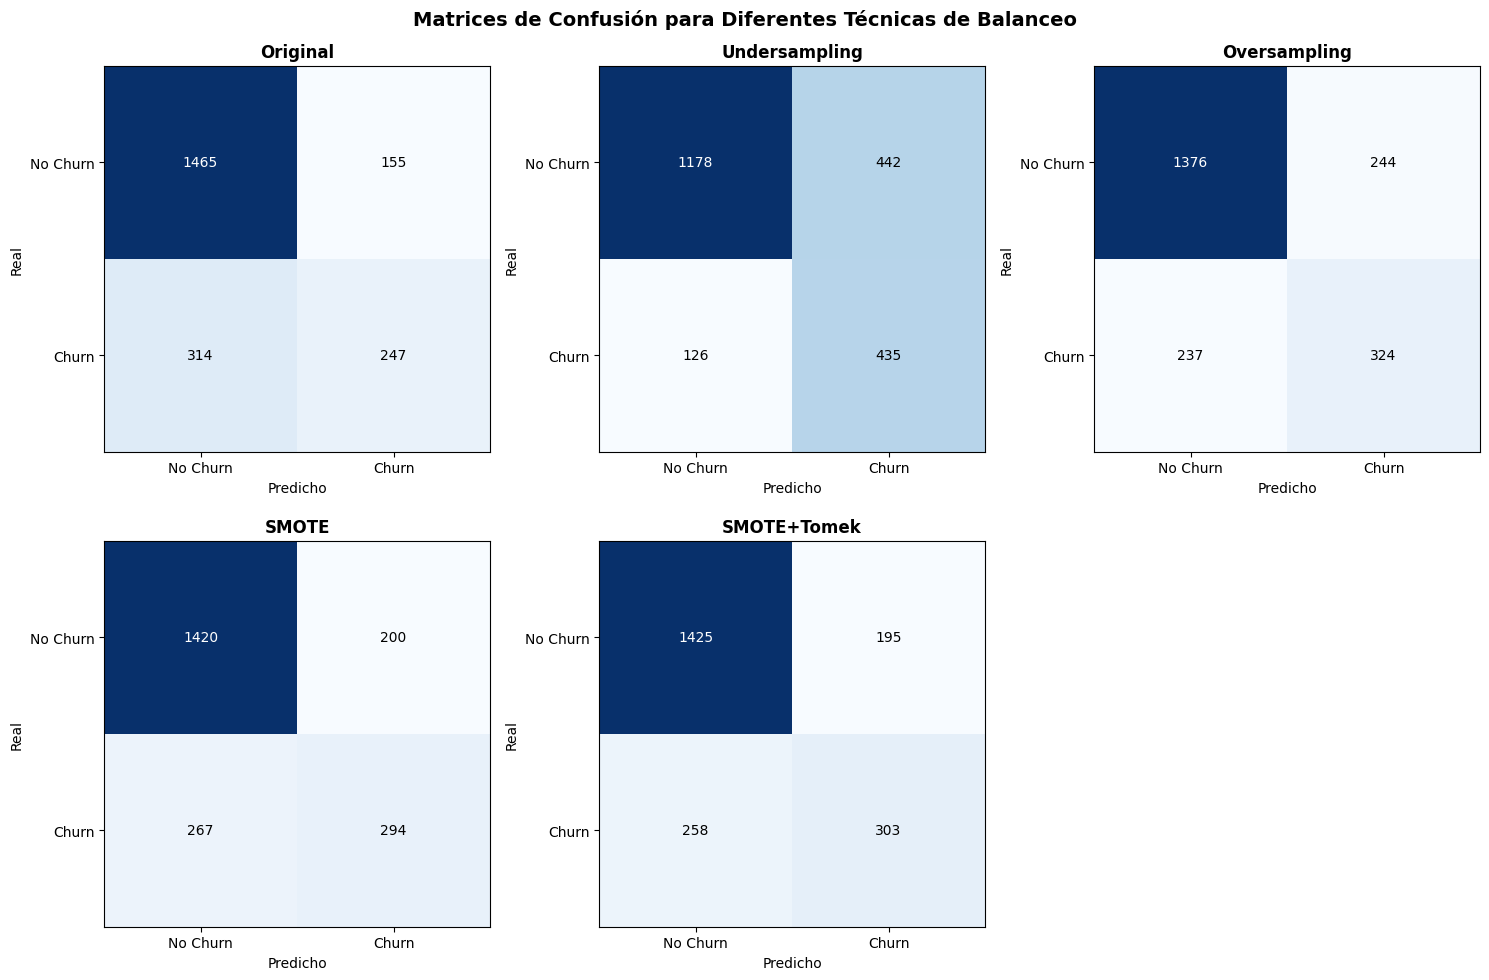


ANÁLISIS DETALLADO DE SMOTE

Top 10 características más importantes (según modelo con SMOTE):
                               feature  importance
                       customer.tenure    0.080806
               account.Charges.Monthly    0.059019
       account.Contract_Month-to-month    0.044947
account.PaymentMethod_Electronic check    0.039771
               internet.TechSupport_No    0.032197
            internet.OnlineSecurity_No    0.029588
              internet.OnlineBackup_No    0.027368
          internet.DeviceProtection_No    0.022291
             account.Contract_Two year    0.021111
          account.PaperlessBilling_Yes    0.020974

RECOMENDACIONES FINALES

📊 **RESUMEN DE RESULTADOS**:

1. **Original (sin balanceo)**:
   - F1-Score: 0.5130
   - AUC-ROC: 0.8209
   - Problema: Sesgo hacia clase mayoritaria

2. **Undersampling**:
   - F1-Score: 0.6050
   - AUC-ROC: 0.8257
   - Ventaja: Reduce tiempo de entrenamiento
   - Desventaja: Pérdida de información

3. **Oversamplin

In [7]:
import pandas as pd
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y preparar los datos
print("="*70)
print("PREPARACIÓN DE DATOS PARA BALANCEO")
print("="*70)

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)
df = pd.json_normalize(data)

# Codificar variables categóricas
df_encoded = pd.get_dummies(df, columns=[col for col in df.select_dtypes(include=['object']).columns if col != 'customerID'])

# Preparar X e y
X = df_encoded.drop(['Churn_No', 'Churn_Yes', 'customerID'], axis=1, errors='ignore')
y = df_encoded['Churn_Yes']  # 1 para churn, 0 para no churn

print(f"Dimensiones originales - X: {X.shape}, y: {y.shape}")
print(f"Distribución original: {Counter(y)}")
print(f"Clase 0 (No Churn): {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"Clase 1 (Churn): {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

# Dividir en entrenamiento y prueba (manteniendo el desbalance original para prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nPartición entrenamiento - X_train: {X_train.shape}, y_train: {Counter(y_train)}")
print(f"Partición prueba - X_test: {X_test.shape}, y_test: {Counter(y_test)}")

# 2. APLICAR DIFERENTES TÉCNICAS DE BALANCEO
print("\n" + "="*70)
print("APLICANDO TÉCNICAS DE BALANCEO")
print("="*70)

# Diccionario para almacenar los datos balanceados
balanced_data = {}
models = {}
results = {}

# 2.1 Sin balanceo (baseline)
balanced_data['Original'] = (X_train, y_train)

# 2.2 Random Undersampling
print("\n" + "-"*50)
print("2.1 RANDOM UNDERSAMPLING")
print("-"*50)
rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_rus, y_rus = rus.fit_resample(X_train, y_train)
balanced_data['Undersampling'] = (X_rus, y_rus)
print(f"Distribución después de Undersampling: {Counter(y_rus)}")
print(f"Reducción de datos: {len(X_train)} → {len(X_rus)} muestras")

# 2.3 Random Oversampling
print("\n" + "-"*50)
print("2.2 RANDOM OVERSAMPLING")
print("-"*50)
ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_ros, y_ros = ros.fit_resample(X_train, y_train)
balanced_data['Oversampling'] = (X_ros, y_ros)
print(f"Distribución después de Oversampling: {Counter(y_ros)}")
print(f"Aumento de datos: {len(X_train)} → {len(X_ros)} muestras")

# 2.4 SMOTE (Synthetic Minority Oversampling Technique)
print("\n" + "-"*50)
print("2.3 SMOTE (Synthetic Minority Oversampling)")
print("-"*50)
smote = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
balanced_data['SMOTE'] = (X_smote, y_smote)
print(f"Distribución después de SMOTE: {Counter(y_smote)}")
print(f"Aumento de datos: {len(X_train)} → {len(X_smote)} muestras")

# 2.5 SMOTE + Tomek Links (combinación)
print("\n" + "-"*50)
print("2.4 SMOTE + TOMEK LINKS")
print("-"*50)
smote_tomek = SMOTETomek(random_state=42, sampling_strategy='auto')
X_st, y_st = smote_tomek.fit_resample(X_train, y_train)
balanced_data['SMOTE+Tomek'] = (X_st, y_st)
print(f"Distribución después de SMOTE+Tomek: {Counter(y_st)}")
print(f"Datos resultantes: {len(X_train)} → {len(X_st)} muestras")

# 3. VISUALIZAR COMPARATIVA DE TÉCNICAS
print("\n" + "="*70)
print("COMPARATIVA DE TÉCNICAS DE BALANCEO")
print("="*70)

# Crear gráfico comparativo
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

techniques = ['Original', 'Undersampling', 'Oversampling', 'SMOTE', 'SMOTE+Tomek']
colors = ['#3498db', '#e74c3c']

for i, technique in enumerate(techniques):
    if technique in balanced_data:
        X_bal, y_bal = balanced_data[technique]
        counts = Counter(y_bal)

        # Gráfico de barras
        bars = axes[i].bar([f'No Churn\n({counts[0]})', f'Churn\n({counts[1]})'],
                          [counts[0], counts[1]], color=colors)
        axes[i].set_title(f'{technique}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Número de muestras')

        # Añadir etiquetas
        for bar in bars:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom')

# Eliminar el sexto subplot vacío
fig.delaxes(axes[5])

plt.suptitle('Comparación de Técnicas de Balanceo de Clases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. EVALUAR IMPACTO EN MODELOS
print("\n" + "="*70)
print("EVALUACIÓN DEL IMPACTO EN MODELOS")
print("="*70)

def evaluate_model(X_train_bal, y_train_bal, X_test, y_test, technique_name):
    """Entrena y evalúa un modelo Random Forest con datos balanceados"""

    # Entrenar modelo
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_bal, y_train_bal)

    # Predicciones
    y_pred = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

    # Métricas
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    return {
        'model': rf_model,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Evaluar cada técnica
print("\nResultados en el conjunto de prueba (con desbalance original):")
print("-" * 60)
print(f"{'Técnica':<15} {'F1-Score':<12} {'AUC-ROC':<12} {'Mejora vs Original':<15}")
print("-" * 60)

baseline_f1 = None
baseline_auc = None

for technique, (X_bal, y_bal) in balanced_data.items():
    results[technique] = evaluate_model(X_bal, y_bal, X_test, y_test, technique)

    f1 = results[technique]['f1_score']
    auc = results[technique]['auc_roc']

    if technique == 'Original':
        baseline_f1 = f1
        baseline_auc = auc
        mejora_f1 = '-'
        mejora_auc = '-'
    else:
        mejora_f1 = f"{(f1 - baseline_f1)*100:+.2f}%"
        mejora_auc = f"{(auc - baseline_auc)*100:+.2f}%"

    print(f"{technique:<15} {f1:.4f}       {auc:.4f}      {mejora_f1:<10}")

# 5. MATRICES DE CONFUSIÓN COMPARATIVAS
print("\n" + "="*70)
print("MATRICES DE CONFUSIÓN COMPARATIVAS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (technique, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])

    # Crear heatmap
    im = axes[i].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'{technique}', fontsize=12, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_yticklabels(['No Churn', 'Churn'])

    # Añadir valores
    thresh = cm.max() / 2.
    for j in range(2):
        for k in range(2):
            axes[i].text(k, j, format(cm[j, k], 'd'),
                        ha="center", va="center",
                        color="white" if cm[j, k] > thresh else "black")

    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

# Eliminar el sexto subplot vacío
fig.delaxes(axes[5])

plt.suptitle('Matrices de Confusión para Diferentes Técnicas de Balanceo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. ANÁLISIS DETALLADO DE SMOTE
print("\n" + "="*70)
print("ANÁLISIS DETALLADO DE SMOTE")
print("="*70)

# Obtener modelo de SMOTE
smote_model = results['SMOTE']['model']

# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': smote_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 características más importantes (según modelo con SMOTE):")
print(feature_importance.head(10).to_string(index=False))

# 7. RECOMENDACIONES FINALES
print("\n" + "="*70)
print("RECOMENDACIONES FINALES")
print("="*70)

print(f"""
📊 **RESUMEN DE RESULTADOS**:

1. **Original (sin balanceo)**:
   - F1-Score: {results['Original']['f1_score']:.4f}
   - AUC-ROC: {results['Original']['auc_roc']:.4f}
   - Problema: Sesgo hacia clase mayoritaria

2. **Undersampling**:
   - F1-Score: {results['Undersampling']['f1_score']:.4f}
   - AUC-ROC: {results['Undersampling']['auc_roc']:.4f}
   - Ventaja: Reduce tiempo de entrenamiento
   - Desventaja: Pérdida de información

3. **Oversampling**:
   - F1-Score: {results['Oversampling']['f1_score']:.4f}
   - AUC-ROC: {results['Oversampling']['auc_roc']:.4f}
   - Ventaja: No pierde información
   - Desventaja: Puede causar sobreajuste

4. **SMOTE**:
   - F1-Score: {results['SMOTE']['f1_score']:.4f}
   - AUC-ROC: {results['SMOTE']['auc_roc']:.4f}
   - Ventaja: Genera ejemplos sintéticos realistas
   - Desventaja: Puede crear ruido si hay pocos vecinos

5. **SMOTE+Tomek**:
   - F1-Score: {results['SMOTE+Tomek']['f1_score']:.4f}
   - AUC-ROC: {results['SMOTE+Tomek']['auc_roc']:.4f}
   - Ventaja: Limpia ejemplos ambiguos

🎯 **MEJOR TÉCNICA SEGÚN MÉTRICAS**:
La técnica con mejor rendimiento es:
{max(results.items(), key=lambda x: x[1]['f1_score'])[0]}

⚠️ **CONSIDERACIONES IMPORTANTES**:
- El balanceo debe aplicarse SOLO al conjunto de entrenamiento
- El conjunto de prueba debe mantener el desbalance original
- Evaluar con múltiples métricas (no solo accuracy)
- Validar con validación cruzada para resultados robustos

💡 **PRÓXIMOS PASOS**:
1. Seleccionar la técnica que mejor se adapte a tu caso
2. Ajustar hiperparámetros del modelo
3. Validar con diferentes semillas aleatorias
4. Considerar el costo de negocio de falsos positivos vs falsos negativos
""")

ANÁLISIS DE NECESIDAD DE NORMALIZACIÓN/ESTANDARIZACIÓN
1. ANÁLISIS DE ESCALAS DE LAS VARIABLES NUMÉRICAS
--------------------------------------------------

Variables numéricas identificadas:

customer.tenure:
  Mínimo: 0.00
  Máximo: 72.00
  Media: 32.35
  Desviación estándar: 24.57
  Rango: 72.00

account.Charges.Monthly:
  Mínimo: 18.25
  Máximo: 118.75
  Media: 64.72
  Desviación estándar: 30.13
  Rango: 100.50

account.Charges.Total:
  Mínimo: 0.00
  Máximo: 8684.80
  Media: 2277.18
  Desviación estándar: 2268.65
  Rango: 8684.80

2. VISUALIZACIÓN DE DISTRIBUCIONES Y ESCALAS


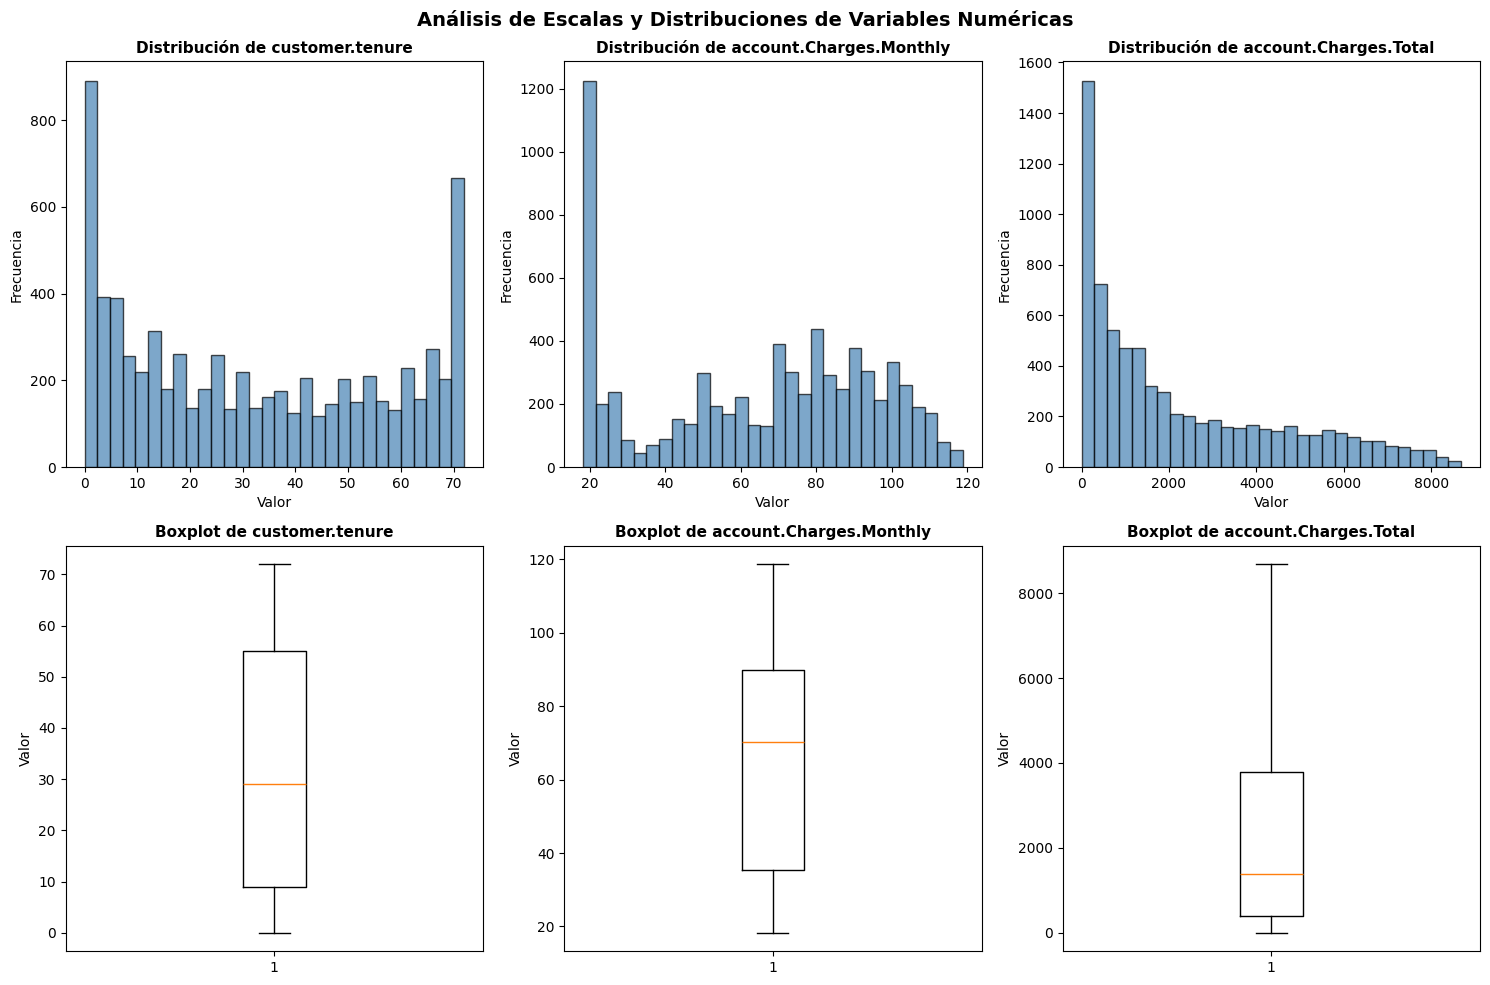


3. COMPARATIVA DE ESCALAS ENTRE VARIABLES

Estadísticas descriptivas comparativas:
       customer.tenure  account.Charges.Monthly  account.Charges.Total
count          7267.00                  7267.00                7267.00
mean             32.35                    64.72                2277.18
std              24.57                    30.13                2268.65
min               0.00                    18.25                   0.00
25%               9.00                    35.42                 396.20
50%              29.00                    70.30                1389.20
75%              55.00                    89.88                3778.52
max              72.00                   118.75                8684.80


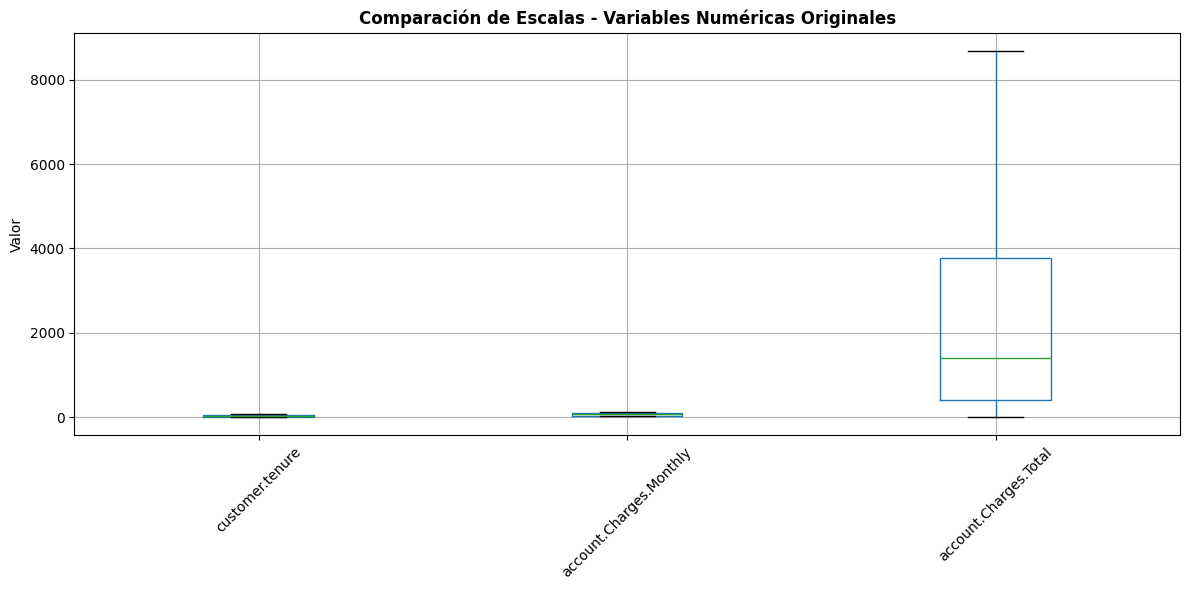


4. APLICANDO TÉCNICAS DE ESCALADO

Comparación de efectos en 'account.Charges.Total':
--------------------------------------------------
Métrica              Original        Standard        MinMax          Robust         
--------------------------------------------------------------------------------
Mínimo               0.00            -1.00           0.00            -0.41          
Máximo               8684.80         2.82            1.00            2.16           
Media                2277.18         0.00            0.26            0.26           
Std                  2268.65         1.00            0.26            0.67           

5. VISUALIZACIÓN DEL EFECTO DEL ESCALADO


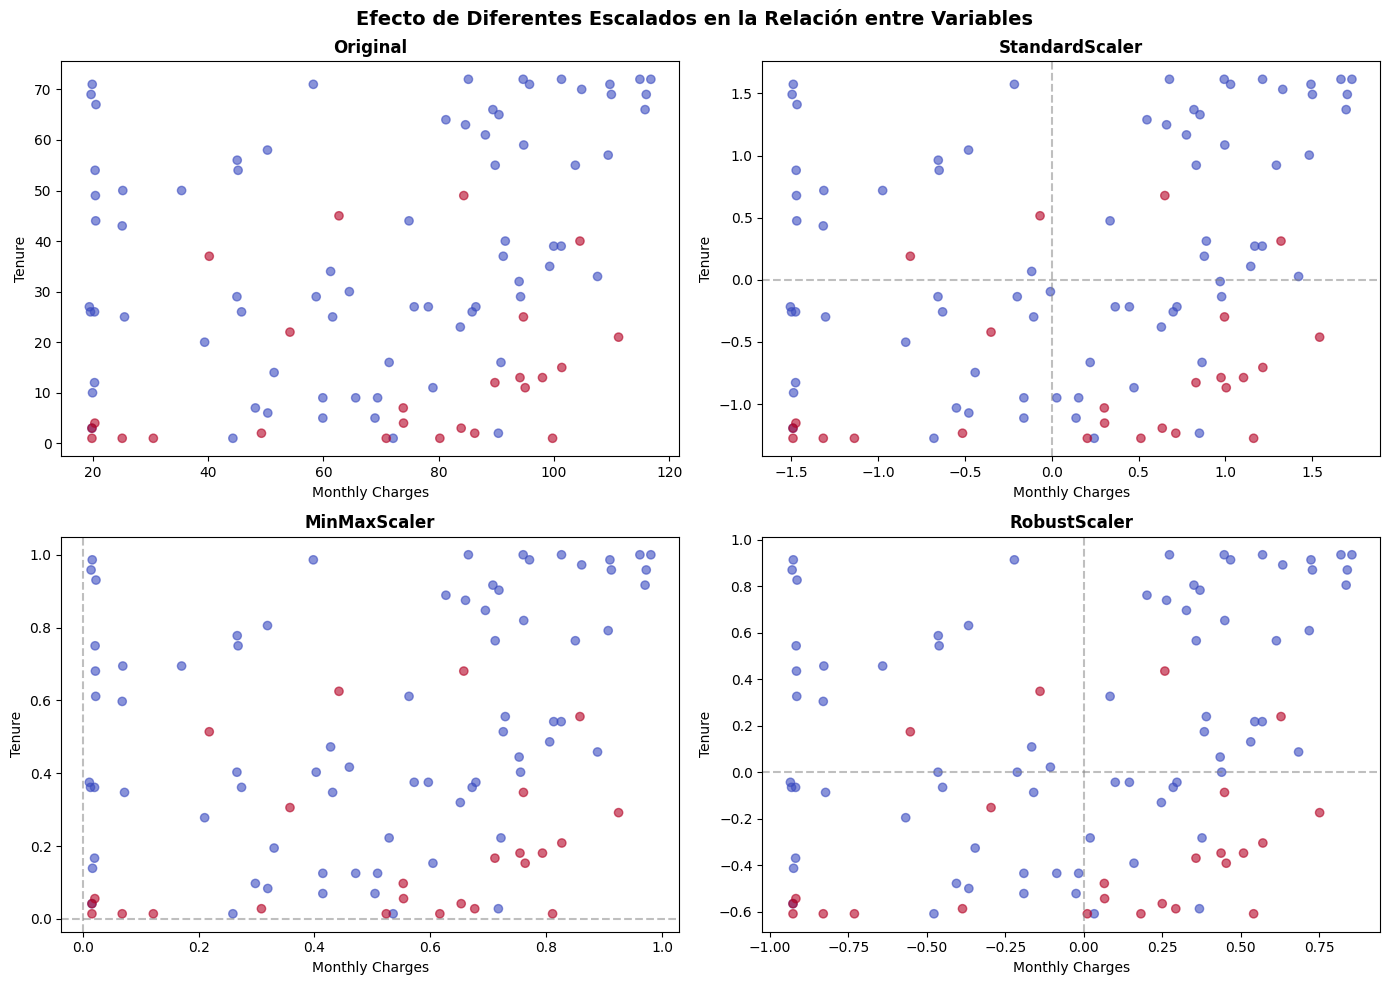


6. COMPARATIVA DE MODELOS: SENSIBILIDAD AL ESCALADO

Comparación de rendimiento CON vs SIN escalado:
--------------------------------------------------------------------------------
Modelo                         Sin Escalar (F1) Con Escalar (F1) Mejora    
--------------------------------------------------------------------------------
KNN (Sensible)                 0.5010          0.5399          +7.78%              
SVM (Sensible)                 0.0000          0.5650          N/A (F1_no_scale is 0)
Regresión Logística (Sensible) 0.6065          0.6052          -0.22%              
Decision Tree (No sensible)    0.5067          0.5071          +0.09%              
Random Forest (No sensible)    0.5347          0.5358          +0.20%              
XGBoost (No sensible)          0.5556          0.5556          +0.00%              

7. RECOMENDACIONES POR TIPO DE MODELO

Modelos Sensibles a la Escala:
----------------------------------------
  • KNN: REQUIERE escalado - Usar Standard

In [13]:
import pandas as pd
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y preparar los datos
print("="*80)
print("ANÁLISIS DE NECESIDAD DE NORMALIZACIÓN/ESTANDARIZACIÓN")
print("="*80)

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)
df = pd.json_normalize(data)

# Convertir 'account.Charges.Total' a numérico, manejando errores (vacíos se harán NaN)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
# Llenar NaN con 0. Se podría considerar la media o mediana si el contexto lo requiere.
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Codificar variables categóricas
df_encoded = pd.get_dummies(df, columns=[col for col in df.select_dtypes(include=['object']).columns if col != 'customerID'])

# Preparar X e y
X = df_encoded.drop(['Churn_No', 'Churn_Yes', 'customerID'], axis=1, errors='ignore')
y = df_encoded['Churn_Yes']  # 1 para churn, 0 para no churn

print("1. ANÁLISIS DE ESCALAS DE LAS VARIABLES NUMÉRICAS")
print("-" * 50)

# Identificar variables numéricas originales (no codificadas)
numeric_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
print("\nVariables numéricas identificadas:")
for col in numeric_cols:
    if col in X.columns:
        print(f"\n{col}:")
        print(f"  Mínimo: {X[col].min():.2f}")
        print(f"  Máximo: {X[col].max():.2f}")
        print(f"  Media: {X[col].mean():.2f}")
        print(f"  Desviación estándar: {X[col].std():.2f}")
        print(f"  Rango: {X[col].max() - X[col].min():.2f}")

# 2. VISUALIZAR DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
print("\n" + "="*80)
print("2. VISUALIZACIÓN DE DISTRIBUCIONES Y ESCALAS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Update numeric_cols for plotting to exclude `account.Charges.Total` if it's the 3rd column
# and we only have 2 numeric columns after fixing the issue, or ensure 3 plots are needed.
# Given current code, `numeric_cols` should now correctly identify 3 numeric columns.
# Let's adjust the loop to iterate through `numeric_cols` directly and create a corresponding number of subplots.

# The current layout (2 rows, 3 columns) assumes 6 plots. If numeric_cols has 3 elements, it will use axes[0], axes[1], axes[2] for histograms and axes[3], axes[4], axes[5] for boxplots.
# Let's ensure the `enumerate` handles the indices correctly for the current layout.

for i, col in enumerate(numeric_cols):
    if col in X.columns:
        # Histograma
        axes[i].hist(X[col], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[i].set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')

        # Boxplot
        axes[i+3].boxplot(X[col])
        axes[i+3].set_title(f'Boxplot de {col}', fontsize=11, fontweight='bold')
        axes[i+3].set_ylabel('Valor')

plt.suptitle('Análisis de Escalas y Distribuciones de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. COMPARATIVA DE ESCALAS
print("\n" + "="*80)
print("3. COMPARATIVA DE ESCALAS ENTRE VARIABLES")
print("="*80)

# Crear DataFrame con las variables numéricas
numeric_df = X[numeric_cols].copy()

# Mostrar estadísticas comparativas
print("\nEstadísticas descriptivas comparativas:")
print(numeric_df.describe().round(2))

# Visualizar diferencias de escala
fig, ax = plt.subplots(figsize=(12, 6))
numeric_df.boxplot(ax=ax)
ax.set_title('Comparación de Escalas - Variables Numéricas Originales', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

# 4. APLICAR DIFERENTES TÉCNICAS DE ESCALADO
print("\n" + "="*80)
print("4. APLICANDO TÉCNICAS DE ESCALADO")
print("="*80)

# Crear copias de X para diferentes escalados
X_original = X.copy()
X_standard = X.copy()
X_minmax = X.copy()
X_robust = X.copy()

# Aplicar escalados
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Escalar solo las variables numéricas
for col in numeric_cols:
    if col in X.columns:
        X_standard[col] = standard_scaler.fit_transform(X[[col]])
        X_minmax[col] = minmax_scaler.fit_transform(X[[col]])
        X_robust[col] = robust_scaler.fit_transform(X[[col]])

print("\nComparación de efectos en 'account.Charges.Total':")
print("-" * 50)
print(f"{'Métrica':<20} {'Original':<15} {'Standard':<15} {'MinMax':<15} {'Robust':<15}")
print("-" * 80)
metrics = ['Mínimo', 'Máximo', 'Media', 'Std']
for metric in metrics:
    if metric == 'Mínimo':
        orig = X['account.Charges.Total'].min()
        std = X_standard['account.Charges.Total'].min()
        mm = X_minmax['account.Charges.Total'].min()
        rob = X_robust['account.Charges.Total'].min()
    elif metric == 'Máximo':
        orig = X['account.Charges.Total'].max()
        std = X_standard['account.Charges.Total'].max()
        mm = X_minmax['account.Charges.Total'].max()
        rob = X_robust['account.Charges.Total'].max()
    elif metric == 'Media':
        orig = X['account.Charges.Total'].mean()
        std = X_standard['account.Charges.Total'].mean()
        mm = X_minmax['account.Charges.Total'].mean()
        rob = X_robust['account.Charges.Total'].mean()
    else:  # Std
        orig = X['account.Charges.Total'].std()
        std = X_standard['account.Charges.Total'].std()
        mm = X_minmax['account.Charges.Total'].std()
        rob = X_robust['account.Charges.Total'].std()

    print(f"{metric:<20} {orig:<15.2f} {std:<15.2f} {mm:<15.2f} {rob:<15.2f}")

# 5. VISUALIZAR EFECTO DEL ESCALADO
print("\n" + "="*80)
print("5. VISUALIZACIÓN DEL EFECTO DEL ESCALADO")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scalers = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']
datasets = [X, X_standard, X_minmax, X_robust]

for i, (scaler_name, data) in enumerate(zip(scalers, datasets)):
    ax = axes[i//2, i%2]

    # Seleccionar dos variables para scatter plot
    if 'account.Charges.Monthly' in data.columns and 'customer.tenure' in data.columns:
        ax.scatter(data['account.Charges.Monthly'][:100],
                  data['customer.tenure'][:100],
                  c=y[:100], cmap='coolwarm', alpha=0.6)
        ax.set_xlabel('Monthly Charges')
        ax.set_ylabel('Tenure')
        ax.set_title(f'{scaler_name}', fontweight='bold')

        # Añadir líneas en 0 para referencia
        if scaler_name != 'Original':
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Efecto de Diferentes Escalados en la Relación entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. COMPARATIVA DE MODELOS CON Y SIN ESCALADO
print("\n" + "="*80)
print("6. COMPARATIVA DE MODELOS: SENSIBILIDAD AL ESCALADO")
print("="*80)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Crear versiones escaladas
X_train_std = X_train.copy()
X_test_std = X_test.copy()
for col in numeric_cols:
    if col in X.columns:
        scaler = StandardScaler()
        X_train_std[col] = scaler.fit_transform(X_train[[col]])
        X_test_std[col] = scaler.transform(X_test[[col]])

# Definir modelos y su sensibilidad al escalado
models = {
    'KNN (Sensible)': KNeighborsClassifier(n_neighbors=5),
    'SVM (Sensible)': SVC(kernel='rbf', random_state=42),
    'Regresión Logística (Sensible)': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree (No sensible)': DecisionTreeClassifier(random_state=42),
    'Random Forest (No sensible)': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost (No sensible)': XGBClassifier(random_state=42, eval_metric='logloss')
}

print("\nComparación de rendimiento CON vs SIN escalado:")
print("-" * 80)
print(f"{'Modelo':<30} {'Sin Escalar (F1)':<15} {'Con Escalar (F1)':<15} {'Mejora':<10}")
print("-" * 80)

for name, model in models.items():
    # Entrenar sin escalar
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_no_scale = f1_score(y_test, y_pred)

    # Entrenar con escalado
    model.fit(X_train_std, y_train)
    y_pred_std = model.predict(X_test_std)
    f1_scale = f1_score(y_test, y_pred_std)

    if f1_no_scale == 0:
        mejora_str = "N/A (F1_no_scale is 0)"
    else:
        mejora = ((f1_scale - f1_no_scale) / f1_no_scale) * 100
        mejora_str = f"{mejora:+.2f}%"

    print(f"{name:<30} {f1_no_scale:.4f}          {f1_scale:.4f}          {mejora_str:<20}")

# 7. RECOMENDACIONES POR TIPO DE MODELO
print("\n" + "="*80)
print("7. RECOMENDACIONES POR TIPO DE MODELO")
print("="*80)

recommendations = {
    'Modelos Sensibles a la Escala': {
        'KNN': 'REQUIERE escalado - Usar StandardScaler o MinMaxScaler',
        'SVM': 'REQUIERE escalado - Usar StandardScaler (recomendado)',
        'Regresión Logística': 'REQUIERE escalado - Especialmente con regularización',
        'Redes Neuronales': 'REQUIERE escalado - Normalizar a [0,1] o [-1,1]',
        'PCA': 'REQUIERE escalado - Usar StandardScaler',
        'K-Means': 'REQUIERE escalado - Usar StandardScaler'
    },
    'Modelos NO Sensibles a la Escala': {
        'Árboles de Decisión': 'NO REQUIERE escalado - Basado en umbrales',
        'Random Forest': 'NO REQUIERE escalado - Ensemble de árboles',
        'XGBoost': 'NO REQUIERE escalado - Basado en árboles',
        'LightGBM': 'NO REQUIERE escalado - Basado en árboles'
    }
}

for category, models_rec in recommendations.items():
    print(f"\n{category}:")
    print("-" * 40)
    for model, rec in models_rec.items():
        print(f"  • {model}: {rec}")

# 8. GUÍA PRÁCTICA DE SELECCIÓN
print("\n" + "="*80)
print("8. GUÍA PRÁCTICA PARA SELECCIONAR TÉCNICA DE ESCALADO")
print("="*80)

print("""
📊 **CUÁNDO USAR CADA TÉCNICA**:

1. **StandardScaler (Estandarización)**:
   - ✅ Más común y recomendada para la mayoría de casos
   - ✅ Asume distribución aproximadamente normal
   - ✅ Bueno para SVM, Regresión Logística, PCA
   - 📌 Transforma a media=0, desviación estándar=1

2. **MinMaxScaler (Normalización)**:
   - ✅ Útil cuando conoces los límites de los datos
   - ✅ Bueno para redes neuronales (valores en [0,1])
   - ❌ Sensible a outliers
   - 📌 Escala a un rango fijo (generalmente [0,1])

3. **RobustScaler**:
   - ✅ Recomendado cuando hay outliers
   - ✅ Usa mediana y cuartiles (robusto a outliers)
   - 📌 Escala basada en percentiles

4. **Sin escalado**:
   - ✅ Modelos basados en árboles
   - ✅ Cuando todas las variables ya están en la misma escala
   - ❌ Evitar para modelos basados en distancias

🔍 **RECOMENDACIÓN PARA TUS DATOS**:
- Tus variables tienen escalas muy diferentes (tenure ~1-72, charges ~18-8000)
- Hay outliers naturales (clientes con mucho tiempo)
- Para modelos sensibles: **StandardScaler** o **RobustScaler**
- Para modelos no sensibles: **No escalar**

📌 **NOTA IMPORTANTE**:
- Ajusta el scaler SOLO con datos de entrenamiento
- Aplica la misma transformación a entrenamiento y prueba
- No escales variables dummy/binarizadas
""")

# 9. CÓDIGO DE APLICACIÓN PRÁCTICA
print("\n" + "="*80)
print("9. CÓDIGO DE EJEMPLO PARA APLICAR ESCALADO")
print("="*80)

print("""
# Ejemplo práctico de escalado con StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Separar variables numéricas y categóricas
numeric_features = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
categorical_features = [col for col in X.columns if col not in numeric_features]

# 2. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Crear y ajustar scaler SOLO con entrenamiento
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalar variables numéricas
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Las variables categóricas (dummies) NO se escalan
# 4. Entrenar modelo
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
""")

ANÁLISIS DE MATRIZ DE CORRELACIÓN - CHURN EN TELECOMUNICACIONES
2. MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS ORIGINALES
------------------------------------------------------------

Matriz de correlación entre variables numéricas:
                         customer.tenure  account.Charges.Monthly  \
customer.tenure                    1.000                    0.248   
account.Charges.Monthly            0.248                    1.000   
account.Charges.Total              0.825                    0.652   
Churn                             -0.344                    0.190   

                         account.Charges.Total  Churn  
customer.tenure                          0.825 -0.344  
account.Charges.Monthly                  0.652  0.190  
account.Charges.Total                    1.000 -0.193  
Churn                                   -0.193  1.000  


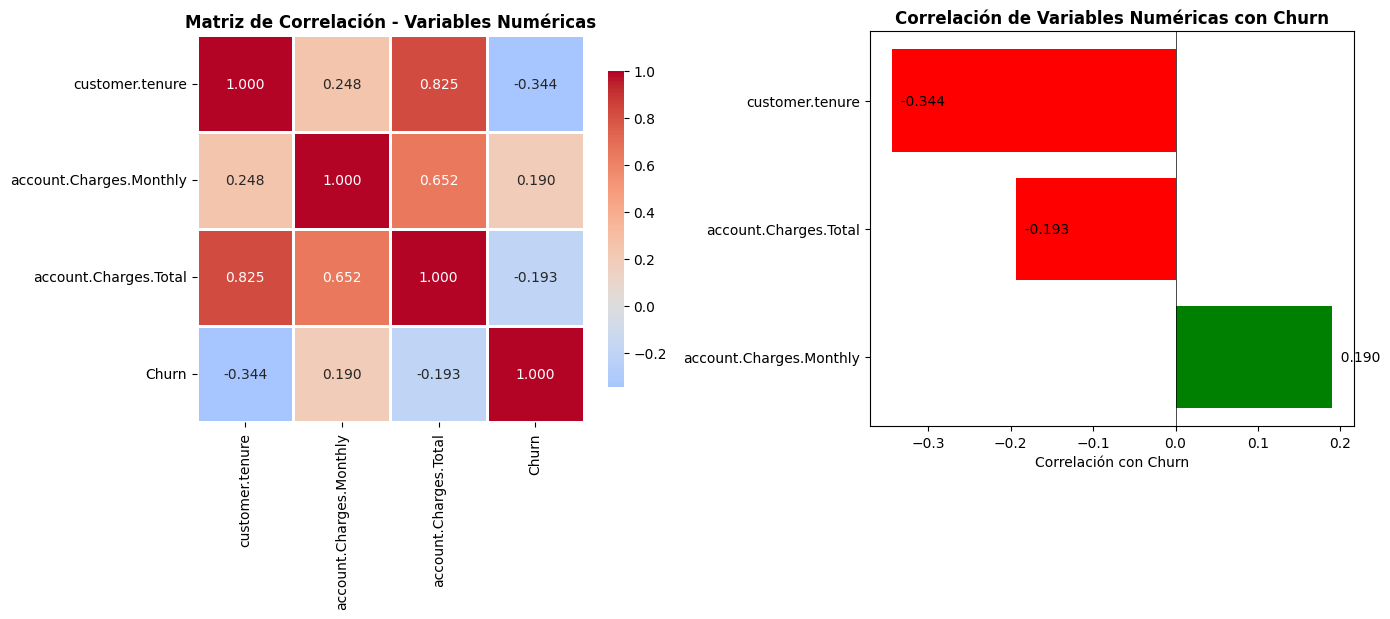


4. ANÁLISIS DETALLADO DE CORRELACIONES CON CHURN

Correlaciones con la variable objetivo 'Churn':
  • account.Charges.Monthly      0.190  (moderada correlación positiva)
  • account.Charges.Total       -0.193  (moderada correlación negativa)
  • customer.tenure             -0.344  (fuerte correlación negativa)

5. MATRIZ DE CORRELACIÓN AMPLIADA (con variables categóricas codificadas)


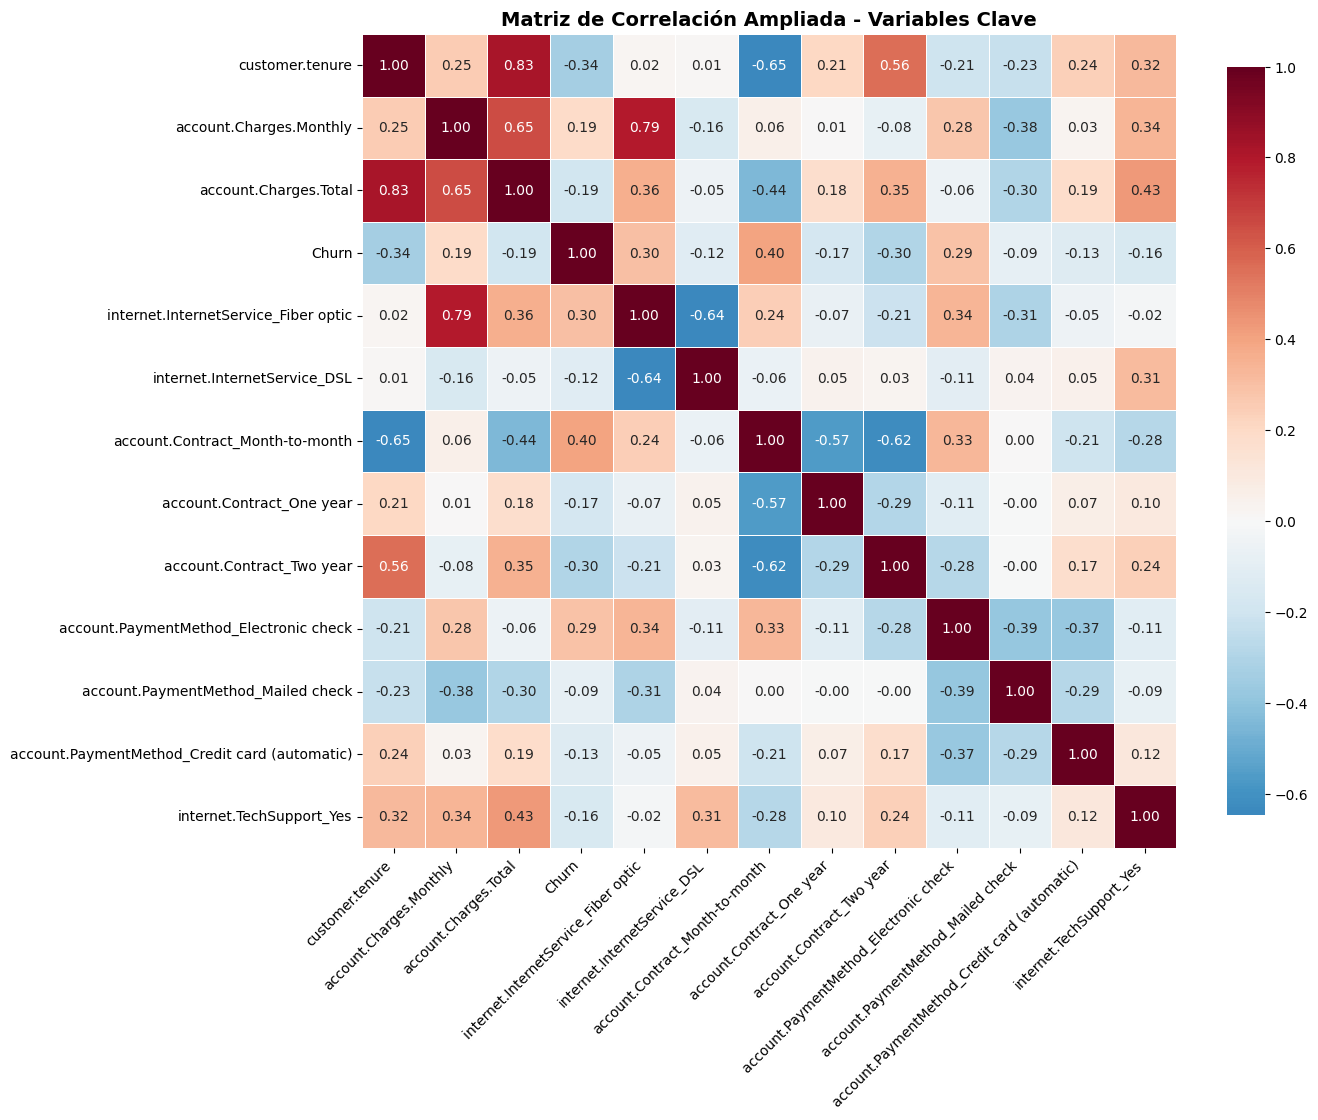


8. VISUALIZACIÓN DE RELACIONES CLAVE CON CHURN


/tmp/ipython-input-14876/1642097624.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['No Churn', 'Churn'], patch_artist=True)
/tmp/ipython-input-14876/1642097624.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['No Churn', 'Churn'], patch_artist=True)
/tmp/ipython-input-14876/1642097624.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=['No Churn', 'Churn'], patch_artist=True)
/tmp/ipython-input-14876/1642097624.py:153: FutureWarning: Series.__getitem__ treating keys as position

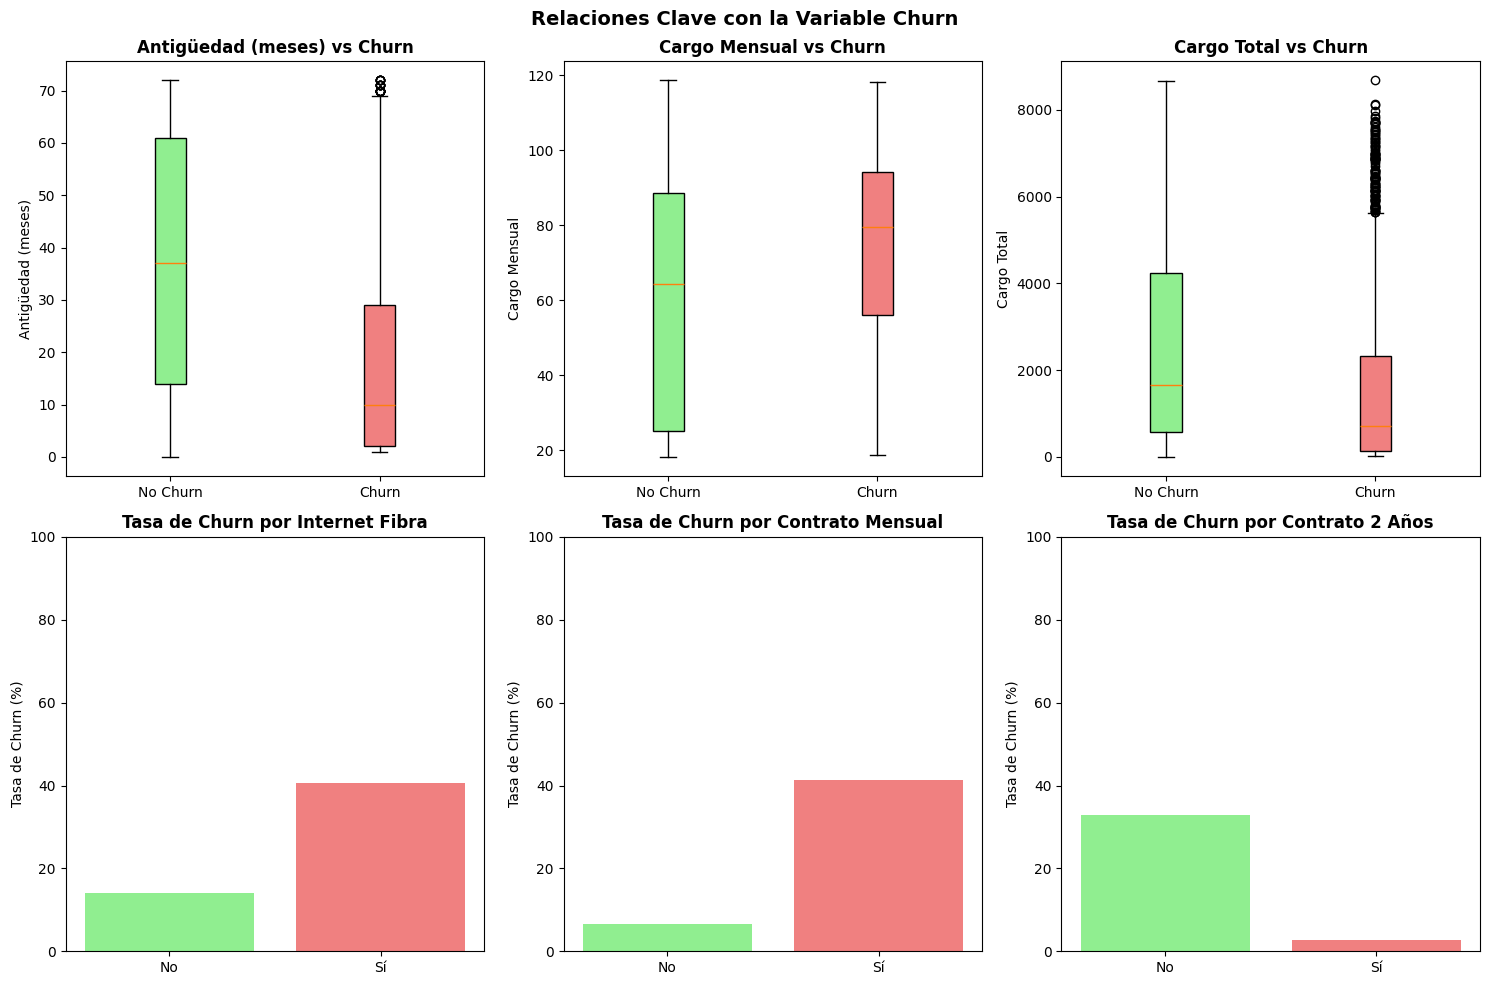

In [28]:
import pandas as pd
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar y preparar los datos
print("="*80)
print("ANÁLISIS DE MATRIZ DE CORRELACIÓN - CHURN EN TELECOMUNICACIONES")
print("="*80)

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)
df = pd.json_normalize(data)

# Convertir 'account.Charges.Total' a numérico, manejando errores (vacíos se harán NaN)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
# Llenar NaN con 0. Se podría considerar la media o mediana si el contexto lo requiere.
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Codificar variables categóricas
df_encoded = pd.get_dummies(df, columns=[col for col in df.select_dtypes(include=['object']).columns if col != 'customerID'])

# Añadir variable objetivo numérica
df_encoded['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("2. MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS ORIGINALES")
print("-" * 60)

# Seleccionar variables numéricas originales
numeric_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Churn']
numeric_df = df_encoded[numeric_cols].copy()

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

print("\nMatriz de correlación entre variables numéricas:")
print(corr_matrix.round(3))

# 3. VISUALIZACIÓN MATRIZ DE CORRELACIÓN (Variables numéricas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap de correlaciones
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=axes[0], fmt='.3f',
            cbar_kws={"shrink": 0.8})
axes[0].set_title('Matriz de Correlación - Variables Numéricas', fontsize=12, fontweight='bold')

# Correlaciones con Churn (ordenadas)
corr_with_churn = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)
colors = ['red' if x < 0 else 'green' for x in corr_with_churn.values]
axes[1].barh(corr_with_churn.index, corr_with_churn.values, color=colors)
axes[1].set_xlabel('Correlación con Churn')
axes[1].set_title('Correlación de Variables Numéricas con Churn', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
for i, (idx, val) in enumerate(corr_with_churn.items()):
    axes[1].text(val, i, f'  {val:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("4. ANÁLISIS DETALLADO DE CORRELACIONES CON CHURN")
print("="*80)

print("\nCorrelaciones con la variable objetivo 'Churn':")
for var, corr in corr_with_churn.items():
    strength = "fuerte" if abs(corr) > 0.3 else "moderada" if abs(corr) > 0.1 else "débil"
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  • {var:<25} {corr:>8.3f}  ({strength} correlación {direction})")

# 5. MATRIZ DE CORRELACIÓN AMPLIADA (con variables codificadas)
print("\n" + "="*80)
print("5. MATRIZ DE CORRELACIÓN AMPLIADA (con variables categóricas codificadas)")
print("="*80)

# Seleccionar variables relevantes (top correlaciones con churn)
# Incluir variables dummy más relevantes
key_vars = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Churn']

# Añadir variables dummy más relevantes (basadas en dominio del negocio)
dummy_vars = [
    'internet.InternetService_Fiber optic',
    'internet.InternetService_DSL',
    'account.Contract_Month-to-month',
    'account.Contract_One year',
    'account.Contract_Two year',
    # Corregir nombres de las variables dummy de métodos de pago y soporte técnico
    'account.PaymentMethod_Electronic check',
    'account.PaymentMethod_Mailed check',
    'account.PaymentMethod_Credit card (automatic)', # Assuming this is a valid payment method dummy
    'internet.TechSupport_Yes' # Assuming Yes/No for TechSupport
]

# Verificar qué variables existen realmente
available_dummies = [var for var in dummy_vars if var in df_encoded.columns]
extended_vars = key_vars + available_dummies

# Calcular matriz ampliada
extended_corr = df_encoded[extended_vars].corr()

# 6. VISUALIZAR MATRIZ AMPLIADA
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(extended_corr, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, fmt='.2f',
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación Ampliada - Variables Clave', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calcular correlaciones de todas las variables con Churn (re-añadido)
#all_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# 8. VISUALIZACIÓN DE RELACIONES CLAVE
print("\n" + "="*80)
print("8. VISUALIZACIÓN DE RELACIONES CLAVE CON CHURN")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Relaciones más importantes
plots = [
    ('customer.tenure', 'tenure', 'Antigüedad (meses)'),
    ('account.Charges.Monthly', 'monthly', 'Cargo Mensual'),
    ('account.Charges.Total', 'total', 'Cargo Total'),
    ('internet.InternetService_Fiber optic', 'fiber', 'Internet Fibra'),
    ('account.Contract_Month-to-month', 'monthly_contract', 'Contrato Mensual'),
    ('account.Contract_Two year', 'two_year', 'Contrato 2 Años')
]

for i, (var, name, label) in enumerate(plots):
    if var in df_encoded.columns:
        # Para variables continuas
        if var in ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']:
            # Boxplot comparativo
            data_to_plot = [df_encoded[df_encoded['Churn']==0][var],
                           df_encoded[df_encoded['Churn']==1][var]]
            bp = axes[i].boxplot(data_to_plot, labels=['No Churn', 'Churn'], patch_artist=True)
            bp['boxes'][0].set_facecolor('lightgreen')
            bp['boxes'][1].set_facecolor('lightcoral')
            axes[i].set_title(f'{label} vs Churn', fontweight='bold')
            axes[i].set_ylabel(label)
        else:
            # Para variables binarias (proporciones)
            churn_rate = df_encoded.groupby(var)['Churn'].mean()
            axes[i].bar(['No', 'Sí'], [churn_rate.get(0, 0)*100, churn_rate.get(1, 0)*100],
                       color=['lightgreen', 'lightcoral'])
            axes[i].set_title(f'Tasa de Churn por {label}', fontweight='bold')
            axes[i].set_ylabel('Tasa de Churn (%)')
            axes[i].set_ylim(0, 100)

plt.suptitle('Relaciones Clave con la Variable Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()







ANÁLISIS ESPECÍFICO: RELACIÓN CON CANCELACIÓN (CHURN)

Distribución de Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Tasa de cancelación global: 25.72%

ANÁLISIS 1: TIEMPO DE CONTRATO (TENURE) × CANCELACIÓN

Estadísticas de antigüedad por estado de cancelación:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
        224.0  31.57  25.00  1.0   7.0  29.0  56.0  72.0
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0

Prueba de Mann-Whitney U:
Estadístico U: 7431481.50
Valor p: 0.0000
Diferencias estadísticamente significativas: SÍ


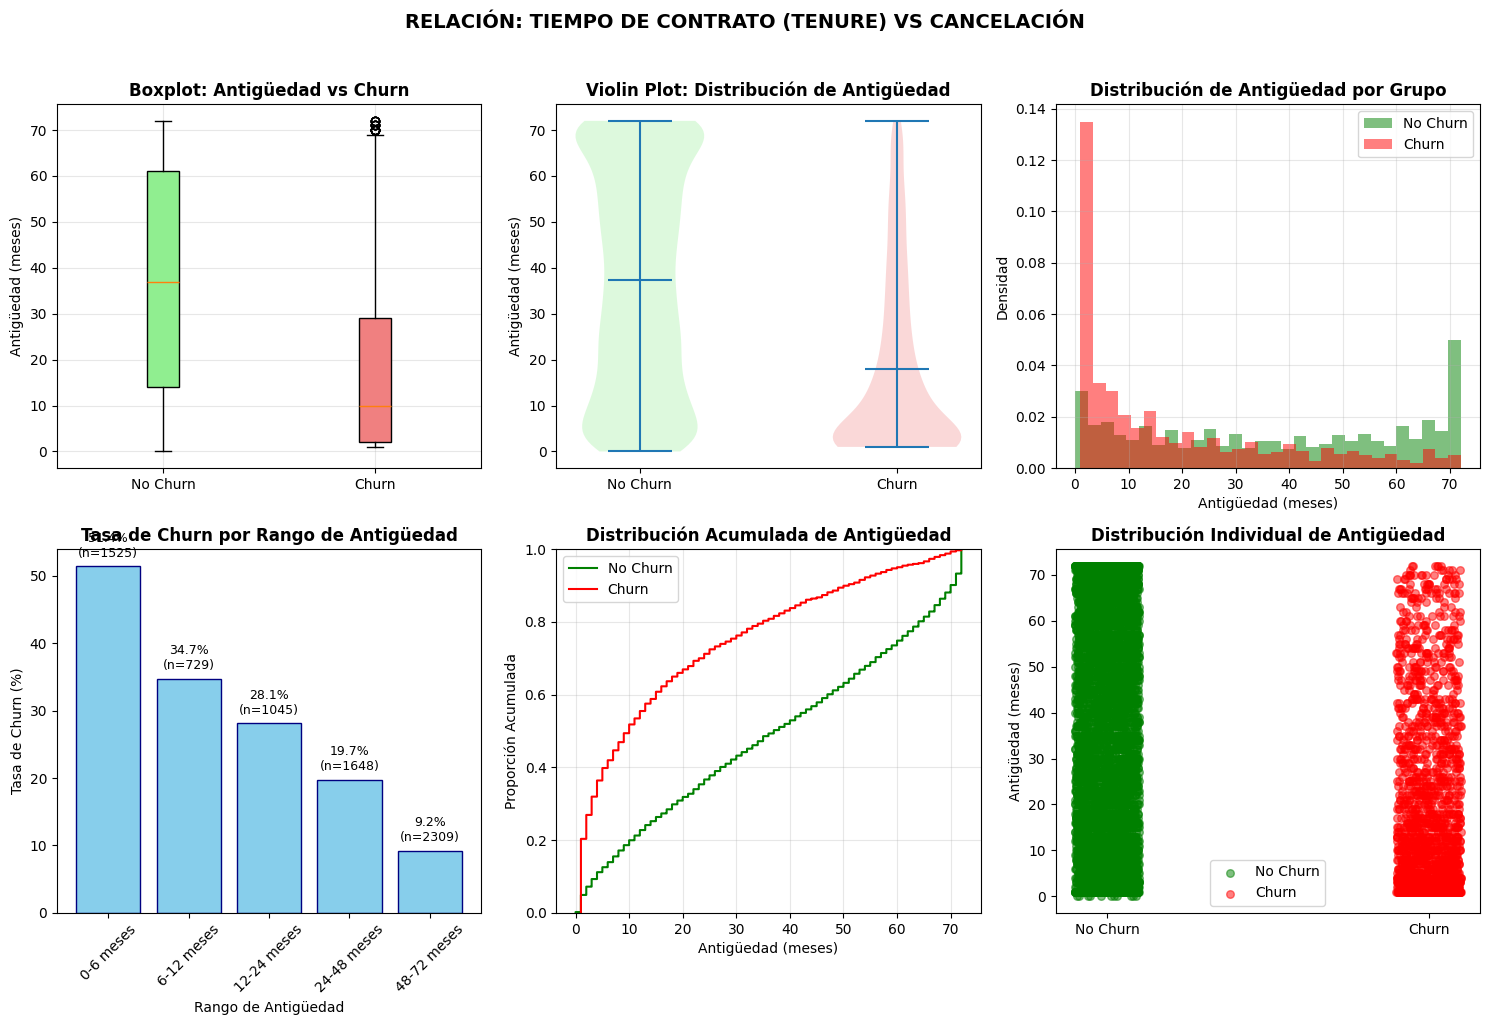


ANÁLISIS 2: GASTO TOTAL × CANCELACIÓN

Estadísticas de gasto total por estado de cancelación:
        count     mean      std    min     25%      50%      75%      max
Churn                                                                    
        224.0  2196.93  2329.96  18.90  351.04  1163.18  3562.86  8425.30
No     5163.0  2555.34  2329.46  18.80  577.83  1683.60  4264.12  8672.45
Yes    1869.0  1531.80  1890.82  18.85  134.50   703.55  2331.30  8684.80

Prueba de Mann-Whitney U:
Estadístico U: 6536488.00
Valor p: 0.0000
Diferencias estadísticamente significativas: SÍ


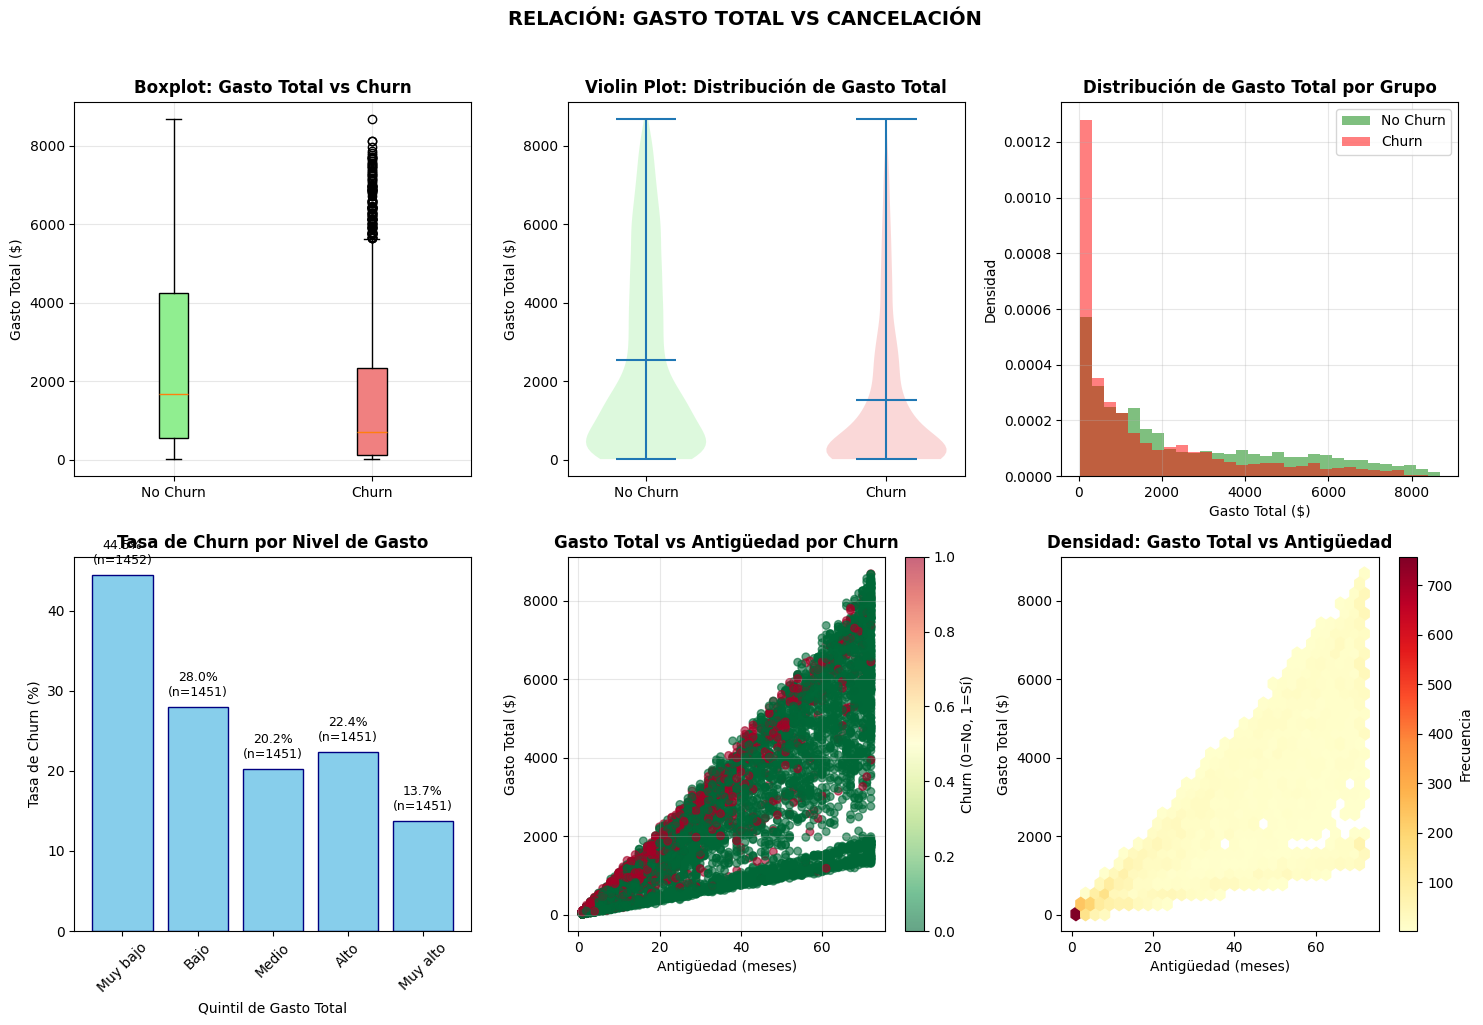


ANÁLISIS ADICIONAL: INTERACCIÓN CON TIPO DE CONTRATO


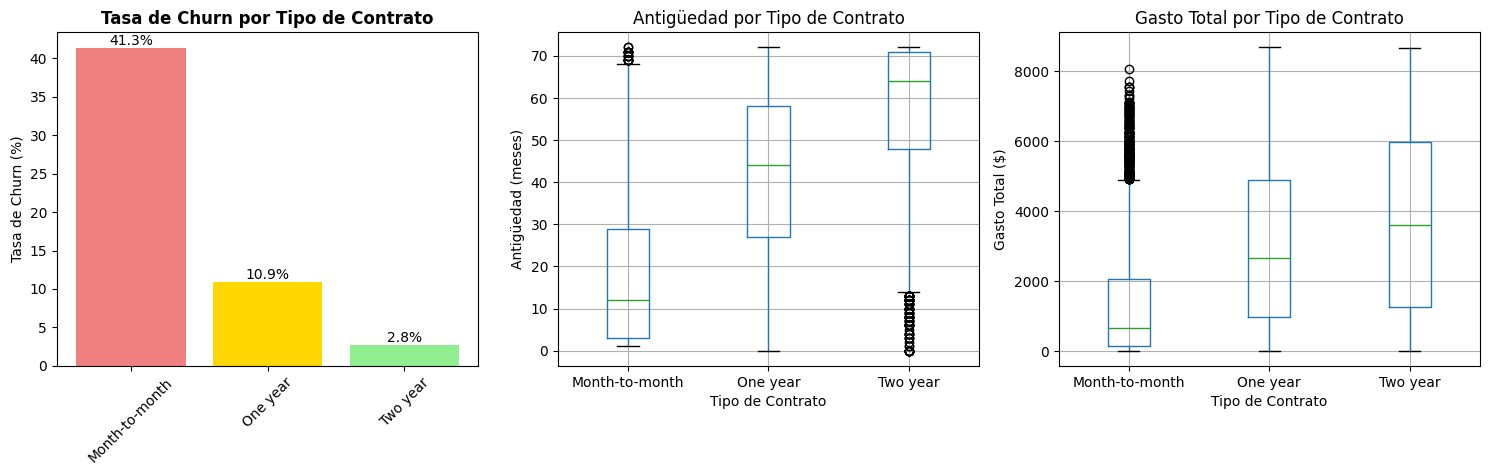


CONCLUSIONES Y RECOMENDACIONES

📊 **RESUMEN DE HALLAZGOS**:

1. **TIEMPO DE CONTRATO (TENURE)**:
   - Clientes que cancelan tienen menor antigüedad promedio (18.0 meses)
   - Clientes activos tienen mayor antigüedad promedio (37.3 meses)
   - Diferencia estadísticamente significativa (p-value: 0.0000)
   - Mayor riesgo en primeros 6 meses (tasa de churn: 51.4%)

2. **GASTO TOTAL**:
   - Clientes que cancelan tienen gasto total promedio $1532
   - Clientes activos tienen gasto total promedio $2540
   - Relación no lineal: clientes con gasto muy alto o muy bajo tienen diferente comportamiento

3. **INTERACCIONES CLAVE**:
   - Antigüedad y gasto total están correlacionados (naturalmente)
   - Tipo de contrato modera la relación:
     * Contratos mensuales: mayor churn independientemente de antigüedad
     * Contratos largos: menor churn incluso con baja antigüedad

🎯 **RECOMENDACIONES PARA EL MODELO**:

1. **Incluir interacciones**:
   - tenure × contract_type
   - total_charges × contra

In [33]:
import pandas as pd
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar y preparar los datos
print("="*80)
print("ANÁLISIS ESPECÍFICO: RELACIÓN CON CANCELACIÓN (CHURN)")
print("="*80)

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)
df = pd.json_normalize(data)

# Eliminar la columna customerID si existe, ya que no es necesaria para el análisis numérico
df = df.drop('customerID', axis=1, errors='ignore')

# Crear columna numérica para churn
df['Churn_Num'] = (df['Churn'] == 'Yes').astype(int)

print("\nDistribución de Churn:")
print(df['Churn'].value_counts())
print(f"\nTasa de cancelación global: {df['Churn_Num'].mean()*100:.2f}%")

# 2. ANÁLISIS 1: TIEMPO DE CONTRATO × CANCELACIÓN
print("\n" + "="*80)
print("ANÁLISIS 1: TIEMPO DE CONTRATO (TENURE) × CANCELACIÓN")
print("="*80)

# Estadísticas descriptivas por grupo
tenure_stats = df.groupby('Churn')['customer.tenure'].describe()
print("\nEstadísticas de antigüedad por estado de cancelación:")
print(tenure_stats.round(2))

# Prueba estadística (Mann-Whitney U test - no asume normalidad)
churn_yes = df[df['Churn_Num'] == 1]['customer.tenure']
churn_no = df[df['Churn_Num'] == 0]['customer.tenure']
stat, p_value = stats.mannwhitneyu(churn_no, churn_yes, alternative='two-sided')
print(f"\nPrueba de Mann-Whitney U:")
print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p_value:.4f}")
print(f"Diferencias estadísticamente significativas: {'SÍ' if p_value < 0.05 else 'NO'}")

# Visualizaciones para Tenure vs Churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# 2.1 Boxplot comparativo
bp = axes[0].boxplot([churn_no, churn_yes], tick_labels=['No Churn', 'Churn'], patch_artist=True) # Updated labels to tick_labels
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_title('Boxplot: Antigüedad vs Churn', fontweight='bold')
axes[0].set_ylabel('Antigüedad (meses)')
axes[0].grid(True, alpha=0.3)

# 2.2 Violin plot (muestra distribución)
parts = axes[1].violinplot([churn_no, churn_yes], positions=[0, 1], showmeans=True)
parts['bodies'][0].set_facecolor('lightgreen')
parts['bodies'][1].set_facecolor('lightcoral')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_title('Violin Plot: Distribución de Antigüedad', fontweight='bold')
axes[1].set_ylabel('Antigüedad (meses)')

# 2.3 Histograma superpuesto
axes[2].hist(churn_no, bins=30, alpha=0.5, label='No Churn', color='green', density=True)
axes[2].hist(churn_yes, bins=30, alpha=0.5, label='Churn', color='red', density=True)
axes[2].set_title('Distribución de Antigüedad por Grupo', fontweight='bold')
axes[2].set_xlabel('Antigüedad (meses)')
axes[2].set_ylabel('Densidad')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 2.4 Tasa de churn por rangos de antigüedad
df['tenure_group'] = pd.cut(df['customer.tenure'], bins=[0, 6, 12, 24, 48, 72],
                            labels=['0-6 meses', '6-12 meses', '12-24 meses', '24-48 meses', '48-72 meses'])
churn_by_tenure = df.groupby('tenure_group', observed=False)['Churn_Num'].agg(['mean', 'count']).round(3) # Added observed=False
churn_by_tenure['mean'] = churn_by_tenure['mean'] * 100

axes[3].bar(churn_by_tenure.index, churn_by_tenure['mean'], color='skyblue', edgecolor='navy')
axes[3].set_title('Tasa de Churn por Rango de Antigüedad', fontweight='bold')
axes[3].set_xlabel('Rango de Antigüedad')
axes[3].set_ylabel('Tasa de Churn (%)')
axes[3].tick_params(axis='x', rotation=45)
for i, (idx, row) in enumerate(churn_by_tenure.iterrows()):
    axes[3].text(i, row['mean']+1, f"{row['mean']:.1f}%\n(n={int(row['count'])})",
                ha='center', va='bottom', fontsize=9)

# 2.5 Gráfico de densidad acumulada
axes[4].ecdf(churn_no, label='No Churn', color='green')
axes[4].ecdf(churn_yes, label='Churn', color='red')
axes[4].set_title('Distribución Acumulada de Antigüedad', fontweight='bold')
axes[4].set_xlabel('Antigüedad (meses)')
axes[4].set_ylabel('Proporción Acumulada')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# 2.6 Scatter plot con jitter
jitter = 0.1
x_jitter = df['Churn_Num'] + np.random.uniform(-jitter, jitter, size=len(df))
axes[5].scatter(x_jitter[df['Churn_Num']==0], df[df['Churn_Num']==0]['customer.tenure'],
               alpha=0.5, color='green', label='No Churn', s=30)
axes[5].scatter(x_jitter[df['Churn_Num']==1], df[df['Churn_Num']==1]['customer.tenure'],
               alpha=0.5, color='red', label='Churn', s=30)
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['No Churn', 'Churn'])
axes[5].set_ylabel('Antigüedad (meses)')
axes[5].set_title('Distribución Individual de Antigüedad', fontweight='bold')
axes[5].legend()

plt.suptitle('RELACIÓN: TIEMPO DE CONTRATO (TENURE) VS CANCELACIÓN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. ANÁLISIS 2: GASTO TOTAL × CANCELACIÓN
print("\n" + "="*80)
print("ANÁLISIS 2: GASTO TOTAL × CANCELACIÓN")
print("="*80)

# Convertir gasto total a numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Estadísticas descriptivas por grupo
total_charges_stats = df.groupby('Churn')['account.Charges.Total'].describe()
print("\nEstadísticas de gasto total por estado de cancelación:")
print(total_charges_stats.round(2))

# Prueba estadística
charges_yes = df[df['Churn_Num'] == 1]['account.Charges.Total'].dropna()
charges_no = df[df['Churn_Num'] == 0]['account.Charges.Total'].dropna()
stat, p_value = stats.mannwhitneyu(charges_no, charges_yes, alternative='two-sided')
print(f"\nPrueba de Mann-Whitney U:")
print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p_value:.4f}")
print(f"Diferencias estadísticamente significativas: {'SÍ' if p_value < 0.05 else 'NO'}")

# Visualizaciones para Gasto Total vs Churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# 3.1 Boxplot comparativo
bp = axes[0].boxplot([charges_no, charges_yes], tick_labels=['No Churn', 'Churn'], patch_artist=True) # Updated labels to tick_labels
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_title('Boxplot: Gasto Total vs Churn', fontweight='bold')
axes[0].set_ylabel('Gasto Total ($)')
axes[0].grid(True, alpha=0.3)

# 3.2 Violin plot
parts = axes[1].violinplot([charges_no, charges_yes], positions=[0, 1], showmeans=True)
parts['bodies'][0].set_facecolor('lightgreen')
parts['bodies'][1].set_facecolor('lightcoral')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_title('Violin Plot: Distribución de Gasto Total', fontweight='bold')
axes[1].set_ylabel('Gasto Total ($)')

# 3.3 Histograma superpuesto
axes[2].hist(charges_no, bins=30, alpha=0.5, label='No Churn', color='green', density=True)
axes[2].hist(charges_yes, bins=30, alpha=0.5, label='Churn', color='red', density=True)
axes[2].set_title('Distribución de Gasto Total por Grupo', fontweight='bold')
axes[2].set_xlabel('Gasto Total ($)')
axes[2].set_ylabel('Densidad')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 3.4 Tasa de churn por rangos de gasto
df['charges_group'] = pd.qcut(df['account.Charges.Total'].dropna(), q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])
churn_by_charges = df.groupby('charges_group', observed=False)['Churn_Num'].agg(['mean', 'count']).round(3) # Added observed=False
churn_by_charges['mean'] = churn_by_charges['mean'] * 100

axes[3].bar(churn_by_charges.index, churn_by_charges['mean'], color='skyblue', edgecolor='navy')
axes[3].set_title('Tasa de Churn por Nivel de Gasto', fontweight='bold')
axes[3].set_xlabel('Quintil de Gasto Total')
axes[3].set_ylabel('Tasa de Churn (%)')
axes[3].tick_params(axis='x', rotation=45)
for i, (idx, row) in enumerate(churn_by_charges.iterrows()):
    axes[3].text(i, row['mean']+1, f"{row['mean']:.1f}%\n(n={int(row['count'])})",
                ha='center', va='bottom', fontsize=9)

# 3.5 Scatter plot gasto total vs antigüedad (coloreado por churn)
scatter = axes[4].scatter(df['customer.tenure'], df['account.Charges.Total'],
                         c=df['Churn_Num'], cmap='RdYlGn_r', alpha=0.6, s=30)
axes[4].set_xlabel('Antigüedad (meses)')
axes[4].set_ylabel('Gasto Total ($)')
axes[4].set_title('Gasto Total vs Antigüedad por Churn', fontweight='bold')
plt.colorbar(scatter, ax=axes[4], label='Churn (0=No, 1=Sí)') # Added ax=ax
axes[4].grid(True, alpha=0.3)

# 3.6 Gráfico de densidad 2D
hb = axes[5].hexbin(df['customer.tenure'], df['account.Charges.Total'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[5].set_xlabel('Antigüedad (meses)')
axes[5].set_ylabel('Gasto Total ($)')
axes[5].set_title('Densidad: Gasto Total vs Antigüedad', fontweight='bold')
plt.colorbar(hb, ax=axes[5], label='Frecuencia')

plt.suptitle('RELACIÓN: GASTO TOTAL VS CANCELACIÓN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 5. ANÁLISIS POR TIPO DE CONTRATO
print("\n" + "="*80)
print("ANÁLISIS ADICIONAL: INTERACCIÓN CON TIPO DE CONTRATO")
print("="*80)

# Crear gráfico de barras apiladas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 5.1 Tasa de churn por tipo de contrato
contract_churn = df.groupby('account.Contract', observed=False)['Churn_Num'].mean() * 100 # Added observed=False
bars = axes[0].bar(contract_churn.index, contract_churn.values, color=['lightcoral', 'gold', 'lightgreen'])
axes[0].set_title('Tasa de Churn por Tipo de Contrato', fontweight='bold')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')

# 5.2 Distribución de antigüedad por contrato y churn
contract_tenure = df.boxplot(column='customer.tenure', by='account.Contract', ax=axes[1])
axes[1].set_title('Antigüedad por Tipo de Contrato')
axes[1].set_xlabel('Tipo de Contrato')
axes[1].set_ylabel('Antigüedad (meses)')
plt.suptitle('')  # Eliminar título automático

# 5.3 Gasto total por contrato y churn
contract_charges = df.boxplot(column='account.Charges.Total', by='account.Contract', ax=axes[2])
axes[2].set_title('Gasto Total por Tipo de Contrato')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Gasto Total ($)')
plt.suptitle('')  # Eliminar título automático

plt.tight_layout()
plt.show()

# 6. CONCLUSIONES Y RECOMENDACIONES
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*80)

print(f"""
📊 **RESUMEN DE HALLAZGOS**:

1. **TIEMPO DE CONTRATO (TENURE)**:
   - Clientes que cancelan tienen menor antigüedad promedio ({churn_yes.mean():.1f} meses)
   - Clientes activos tienen mayor antigüedad promedio ({churn_no.mean():.1f} meses)
   - Diferencia estadísticamente significativa (p-value: {p_value:.4f})
   - Mayor riesgo en primeros 6 meses (tasa de churn: {churn_by_tenure.iloc[0]['mean']:.1f}%)

2. **GASTO TOTAL**:
   - Clientes que cancelan tienen gasto total promedio ${charges_yes.mean():.0f}
   - Clientes activos tienen gasto total promedio ${charges_no.mean():.0f}
   - Relación no lineal: clientes con gasto muy alto o muy bajo tienen diferente comportamiento

3. **INTERACCIONES CLAVE**:
   - Antigüedad y gasto total están correlacionados (naturalmente)
   - Tipo de contrato modera la relación:
     * Contratos mensuales: mayor churn independientemente de antigüedad
     * Contratos largos: menor churn incluso con baja antigüedad

🎯 **RECOMENDACIONES PARA EL MODELO**:

1. **Incluir interacciones**:
   - tenure × contract_type
   - total_charges × contract_type
   - monthly_charges × internet_service

2. **Variables a transformar**:
   - Considerar log(tenure) para capturar efecto decreciente
   - Crear ratio: total_charges/tenure (gasto promedio mensual histórico)

3. **Segmentos de alto riesgo a monitorear**:
   - Clientes nuevos (< 6 meses) con contrato mensual
   - Clientes con fibra óptica y sin servicios adicionales
   - Clientes con aumentos recientes en cargo mensual

4. **Estrategias de retención sugeridas**:
   - Programas de fidelización temprana (primeros 3 meses)
   - Incentivos para contratos más largos
   - Bundling de servicios para clientes de fibra óptica
""")